# Bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from scipy.stats import randint
from xgboost import XGBClassifier

# Funções

In [2]:
def cria_features_temporais(df):
    """
    Cria features temporais a partir das datas de emissão e vencimento do documento.
    """
    df_copy = df.copy()
    df_copy['dias_prazo'] = (
        (df_copy['data_vencimento'] - df_copy['data_emissao_documento'])
        .dt.days
        .clip(lower=0)
        )

    for col, prefix in [('data_emissao_documento', 'emissao'), ('data_vencimento', 'vencimento')]:
        df_copy[f'{prefix}_dia']              = df_copy[col].dt.day
        df_copy[f'{prefix}_mes']              = df_copy[col].dt.month
        df_copy[f'{prefix}_ano']              = df_copy[col].dt.year
        df_copy[f'{prefix}_dia_semana']       = df_copy[col].dt.dayofweek  # 0=segunda
        df_copy[f'{prefix}_trimestre']        = df_copy[col].dt.quarter
        df_copy[f'{prefix}_fim_de_semana']    = (df_copy[col].dt.dayofweek >= 5).astype(int)
        df_copy[f'{prefix}_fim_de_mes']       = (df_copy[col].dt.day >= 25).astype(int)
        df_copy[f'{prefix}_inicio_mes']       = (df_copy[col].dt.day <= 5).astype(int)

    return df_copy

In [3]:
def plot_curva_precision_recall(y_test, y_probs):
    """
    Plota a Curva Precision-Recall e calcula o Average Precision (AP).
    Métrica mais informativa que ROC-AUC quando a classe positiva
    é minoritária (foca diretamente em quão bem o modelo separa
    os inadimplentes, sem diluir pela classe majoritária).
    """
    ap = average_precision_score(y_test, y_probs)
    print(f"Average Precision (PR-AUC): {ap:.2f}")

    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    baseline = y_test.mean()  # proporção da classe positiva

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', label=f'AP = {ap:.2f}')
    plt.axhline(
        baseline,
        color='red',
        linestyle='--',
        label=f'Baseline (aleatório) = {baseline:.2f}')
    plt.xlabel('Recall (Sensibilidade)')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend()
    plt.show()

In [5]:
def plot_matriz_corr(X, limite_corr=0.75, figsize=(14, 14)):
    """
    Plota a matriz de correlação das features
    e identifica variáveis altamente correlacionadas (>= 0.75).
    """
    corr_matrix = X.corr(numeric_only=True)

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Matriz de Correlação das Features")
    plt.show()

    # Filtrando correlações altas
    upper_tri_limpo = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    colunas_alta_corr = [column for column in upper_tri_limpo.columns if any(abs(upper_tri_limpo[column]) >= limite_corr)]

    print(f"Variáveis para exclusão por correlação >= {limite_corr}:\n{colunas_alta_corr}")

    return corr_matrix, colunas_alta_corr

In [6]:
def analise_overfitting(modelo, X_treino, y_probs_teste):
    y_probs_treino = modelo.predict_proba(X_treino)[:, 1]

    brier_treino = brier_score_loss(y_treino, y_probs_treino)
    brier_teste  = brier_score_loss(y_teste, y_probs_teste)

    auc_treino = roc_auc_score(y_treino, y_probs_treino)
    auc_teste  = roc_auc_score(y_teste, y_probs_teste)

    logloss_treino = log_loss(y_treino, y_probs_treino)
    logloss_teste  = log_loss(y_teste, y_probs_teste)

    avg_precision_treino = average_precision_score(y_treino, y_probs_treino)
    avg_precision_teste  = average_precision_score(y_teste, y_probs_teste)

    print(f"--- ANÁLISE DE OVERFITTING ---")
    print(f"Brier Score     | Treino: {brier_treino:.4f} | Teste: {brier_teste:.4f}")
    print(f"ROC-AUC         | Treino: {auc_treino:.4f} | Teste: {auc_teste:.4f}")
    print(f"Log Loss        | Treino: {logloss_treino:.4f} | Teste: {logloss_teste:.4f}")
    print(f"Avg Precision   | Treino: {avg_precision_treino:.4f} | Teste: {avg_precision_teste:.4f}")

In [7]:
def plot_matriz_confusao(y_teste, y_pred, normalize='true', nome_modelo=None):
    """
    Plota a matriz de confusão com base nos resultados de teste e predição
    com cutoff de 0.5
    """
    cm_pct = confusion_matrix(
        y_teste,
        y_pred,
        normalize=normalize
    )

    fig, ax = plt.subplots(figsize=(6, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_pct,
        display_labels=['Adimplente (0)', 'Inadimplente (1)']
    )

    if normalize in ('true', 'pred'):
        disp.plot(cmap='Blues', values_format='.2%', colorbar=False, ax=ax)
    else:
        disp.plot(cmap='Blues', colorbar=False, ax=ax)

    ax.grid(False)
    ax.set_title(nome_modelo, fontsize=11, pad=8)
    ax.set_ylabel('Situação Real', fontsize=9)
    ax.set_xlabel('Situação Predita', fontsize=9)

    plt.tight_layout()
    plt.show()

In [8]:
def calcula_metricas(y_teste, y_pred=None, y_probs=None,  nome_modelo=None):
    """
    Calcula dinamicamente métricas de classificação e ranking 
    com base nas predições e/ou probabilidades fornecidas.
    """
    metricas = {}
    metricas['nome_modelo']     = nome_modelo
    # Métricas baseadas na predição binária (threshold aplicado)
    if y_pred is not None:
        metricas['recall']      = recall_score(y_teste, y_pred, zero_division=0)
        metricas['precision']   = precision_score(y_teste, y_pred, zero_division=0)
        metricas['accuracy']    = accuracy_score(y_teste, y_pred)
        metricas['f1_score']    = f1_score(y_teste, y_pred, zero_division=0)
        tn, fp, fn, tp          = confusion_matrix(y_teste, y_pred).ravel()
        metricas['tn']          = tn
        metricas['fp']          = fp
        metricas['fn']          = fn
        metricas['tp']          = tp
        
    # Métricas baseadas nas probabilidades
    if y_probs is not None:
        metricas['roc_auc']         = roc_auc_score(y_teste, y_probs)
        metricas['avg_precision']   = average_precision_score(y_teste, y_probs)
        metricas['brier_score']     = brier_score_loss(y_teste, y_probs)
        
    return metricas

# Base cadastral

In [9]:
# Utiliza pathlib para garantir compatibilidade
# entre Windows, Linux e macOS
DATA_DIR = Path("data")

In [10]:
df_base_cadast = pd.read_csv(
    DATA_DIR / "base_cadastral.csv",
    sep=';',
    encoding='utf-8'
    )

df_base_cadast.columns = df_base_cadast.columns.str.lower()
df_base_cadast['id_cliente'] = df_base_cadast['id_cliente'].astype(str)

# Para evitar problemas com caracteres especiais
df_base_cadast['segmento_industrial'] = (
    df_base_cadast['segmento_industrial']
    .replace(
        {
            'Serviços':  'servicos',
            'Comércio':  'comercio',
            'Indústria': 'industria'
        }
    )
)

df_base_cadast['porte'] = df_base_cadast['porte'].str.lower()
df_base_cadast['dominio_email'] = df_base_cadast['dominio_email'].str.lower()

# Cria dummie 1 = PF e 0 = PJ
df_base_cadast['flag_pf'] = (
    df_base_cadast['flag_pf']
    .map({'X': 1, np.nan: 0})
    .astype(int)
    )

# Limpa os ddd que contém caracteres além de números
df_base_cadast['ddd'] = (
    df_base_cadast['ddd']
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
)

# Trata CEP e converte para float para modelagem
df_base_cadast['cep_2_dig'] = df_base_cadast['cep_2_dig'].replace({'na': np.nan}).astype(float)

df_base_cadast['data_cadastro'] = pd.to_datetime(df_base_cadast['data_cadastro'])

df_base_cadast = (
    df_base_cadast
    .sort_values(['id_cliente', 'data_cadastro'])
    .reset_index(drop=True)
    )

df_base_cadast

,id_cliente,data_cadastro,ddd,flag_pf,segmento_industrial,dominio_email,porte,cep_2_dig
0,1000372849175668062,2011-02-14,17.0,0,industria,hotmail,grande,14.0
1,1002362614649347438,2015-01-11,62.0,0,comercio,outlook,medio,74.0
2,1003144834589372198,2017-08-06,49.0,0,servicos,outlook,pequeno,89.0
3,1007951122586612702,2011-02-14,33.0,0,comercio,bol,pequeno,39.0
4,1028630885537616736,2017-08-09,28.0,0,industria,yahoo,pequeno,29.0
...,...,...,...,...,...,...,...,...
1310,968199235777440720,2011-02-15,67.0,0,servicos,yahoo,medio,79.0
1311,968400235888951633,2014-02-02,NaN,0,comercio,yahoo,pequeno,95.0
1312,984915269987074754,2011-02-14,17.0,0,servicos,NaN,grande,15.0
1313,985215297182099989,2003-05-06,45.0,0,industria,gmail,grande,85.0


In [11]:
df_base_cadast.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_cliente           1315 non-null   object        
 1   data_cadastro        1315 non-null   datetime64[ns]
 2   ddd                  1078 non-null   float64       
 3   flag_pf              1315 non-null   int64         
 4   segmento_industrial  1232 non-null   object        
 5   dominio_email        1285 non-null   object        
 6   porte                1274 non-null   object        
 7   cep_2_dig            1314 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 82.3+ KB


In [12]:
df_base_cadast.isna().sum()

id_cliente               0
data_cadastro            0
ddd                    237
flag_pf                  0
segmento_industrial     83
dominio_email           30
porte                   41
cep_2_dig                1
dtype: int64

In [13]:
# Identifica se há ids repetidos
if df_base_cadast['id_cliente'].nunique() != df_base_cadast.shape[0]:
    print('Há id repetido')
else:
    print('Não há id repetido')

Não há id repetido


In [14]:
# Agrupando os dados para o gráfico de barras
df_porte_segmento = (
    df_base_cadast.groupby(['segmento_industrial', 'porte'], dropna=False)
    .size()
    .reset_index(name='quantidade')
)

# Gráfico de barras agrupadas por Segmento e Porte
fig = px.bar(
    df_porte_segmento,
    x='segmento_industrial',
    y='quantidade',
    color='porte',
    barmode='group',
    title='Volume de Clientes por Segmento Industrial e Porte',
    labels={
        'segmento_industrial': 'Segmento Industrial',
        'quantidade': 'Quantidade de Clientes',
        'porte': 'Porte da Empresa'
    },
    text_auto=True
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, showticklabels=False, gridcolor='lightgray'),
    legend_title_text='Porte'
)

fig.show()

In [15]:
flag_pf_0 = df_base_cadast[df_base_cadast['flag_pf'] == 0].shape[0]
flag_pf_1 = df_base_cadast[df_base_cadast['flag_pf'] == 1].shape[0]

total_clientes = df_base_cadast.shape[0]

pct_pf_0 = np.round((flag_pf_0 / total_clientes) * 100, 2)
pct_pf_1 = np.round((flag_pf_1 / total_clientes) * 100, 2)

# Criando um DataFrame auxiliar para o gráfico de proporção
df_pf_counts = pd.DataFrame({
    'tipo_cliente': ['PJ', 'PF'],
    'quantidade': [pct_pf_0, pct_pf_1]
})

fig = px.bar(
    df_pf_counts,
    x='tipo_cliente',
    y='quantidade',
    title='Proporção de Clientes: Pessoa Física vs Pessoa Jurídica',
    labels={
        'tipo_cliente': 'Tipo de Cliente',
        'quantidade': 'Qt. Clientes'
    },
    text_auto=True,
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(
        showgrid=True,
        showticklabels=False,
        gridcolor='lightgray',
        title='% Clientes'
    ),
    showlegend=False
)

fig.show()

## Análise dos clientes por Estado

In [16]:
# Relação entre os dois primeiros digitos do CEP e os estados brasileiros
ceps_uf = {
    "10": "SP", "11": "SP", "12": "SP", "13": "SP", "14": "SP",
    "15": "SP", "16": "SP", "17": "SP", "18": "SP", "19": "SP",
    "20": "RJ", "21": "RJ", "22": "RJ", "23": "RJ", "24": "RJ",
    "25": "RJ", "26": "RJ", "27": "RJ", "28": "RJ", "29": "RJ",
    "30": "MG", "31": "MG", "32": "MG", "33": "MG", "34": "MG",
    "35": "MG", "36": "MG", "37": "MG", "38": "MG", "39": "MG",
    "40": "BA", "41": "BA", "42": "BA", "43": "BA", "44": "BA",
    "45": "BA", "46": "BA", "47": "BA", "48": "BA", "49": "BA",
    "50": "MS", "51": "MS", "52": "GO", "53": "DF", "54": "RS",
    "55": "RS", "56": "RS", "57": "AL", "58": "PB", "59": "RN",
    "60": "CE", "61": "CE", "62": "CE", "63": "CE", "64": "CE",
    "65": "CE", "66": "CE", "67": "CE", "68": "PA", "69": "RO",
    "70": "DF", "71": "DF", "72": "DF", "73": "DF", "74": "DF",
    "75": "DF", "76": "DF", "77": "DF", "78": "MT", "79": "SE",
    "80": "PR", "81": "PR", "82": "PR", "83": "PR", "84": "PR",
    "85": "PR", "86": "PR", "87": "PR", "88": "SC", "89": "SC",
    "90": "RS", "91": "RS", "92": "RS", "93": "RS", "94": "RS",
    "95": "RS", "96": "AP", "97": "AM", "98": "MA", "99": "MA"
}

In [17]:
df_ceps_brasil = pd.DataFrame(list(ceps_uf.items()), columns=['cep_2_dig', 'uf'])
df_ceps_brasil['cep_2_dig'] = df_ceps_brasil['cep_2_dig'].astype('Int64')
df_ceps_brasil

,cep_2_dig,uf
0,10,SP
1,11,SP
2,12,SP
3,13,SP
4,14,SP
...,...,...
85,95,RS
86,96,AP
87,97,AM
88,98,MA


In [18]:
df_base_cadast_uf = df_base_cadast.merge(df_ceps_brasil, on='cep_2_dig', how='left')
df_base_cadast_uf

,id_cliente,data_cadastro,ddd,flag_pf,segmento_industrial,dominio_email,porte,cep_2_dig,uf
0,1000372849175668062,2011-02-14,17.0,0,industria,hotmail,grande,14.0,SP
1,1002362614649347438,2015-01-11,62.0,0,comercio,outlook,medio,74.0,DF
2,1003144834589372198,2017-08-06,49.0,0,servicos,outlook,pequeno,89.0,SC
3,1007951122586612702,2011-02-14,33.0,0,comercio,bol,pequeno,39.0,MG
4,1028630885537616736,2017-08-09,28.0,0,industria,yahoo,pequeno,29.0,RJ
...,...,...,...,...,...,...,...,...,...
1310,968199235777440720,2011-02-15,67.0,0,servicos,yahoo,medio,79.0,SE
1311,968400235888951633,2014-02-02,NaN,0,comercio,yahoo,pequeno,95.0,RS
1312,984915269987074754,2011-02-14,17.0,0,servicos,NaN,grande,15.0,SP
1313,985215297182099989,2003-05-06,45.0,0,industria,gmail,grande,85.0,PR


## Tratamento de dados nulos

In [19]:
df_base_cadast_uf.isna().sum()

id_cliente               0
data_cadastro            0
ddd                    237
flag_pf                  0
segmento_industrial     83
dominio_email           30
porte                   41
cep_2_dig                1
uf                       1
dtype: int64

In [20]:
df_base_cadast_uf_nulos = df_base_cadast_uf[
    [
        'segmento_industrial',
        'dominio_email',
        'porte',
        'uf'
    ]
    ].isnull().sum()
perc_df_base_cadast_uf_nulos = (df_base_cadast_uf_nulos / len(df_base_cadast_uf) * 100).round(2)

resumo_df_base_cadast_uf_nulos = pd.DataFrame({'qtd_nulos': df_base_cadast_uf_nulos, 'pct_nulos': perc_df_base_cadast_uf_nulos})
resumo_df_base_cadast_uf_nulos

,qtd_nulos,pct_nulos
segmento_industrial,83,6.31
dominio_email,30,2.28
porte,41,3.12
uf,1,0.08


In [21]:
colunas_cat_base_cadast_uf = [
    "segmento_industrial",
    "dominio_email",
    "porte",
    "uf"
]

df_base_cadast_uf_tratado = df_base_cadast_uf.copy()

# Cria dummies para modelo
for col in colunas_cat_base_cadast_uf:
    df_base_cadast_uf_tratado[col + '_imputado'] = df_base_cadast_uf_tratado[col].isnull().astype(int)

for col in colunas_cat_base_cadast_uf:
    df_base_cadast_uf_tratado[col] = df_base_cadast_uf_tratado[col].fillna("Desconhecido")

In [22]:
df_base_cadast_uf_tratado.isna().sum()

id_cliente                        0
data_cadastro                     0
ddd                             237
flag_pf                           0
segmento_industrial               0
dominio_email                     0
porte                             0
cep_2_dig                         1
uf                                0
segmento_industrial_imputado      0
dominio_email_imputado            0
porte_imputado                    0
uf_imputado                       0
dtype: int64

In [23]:
df_uf_pct = (
    df_base_cadast_uf_tratado['uf']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index(name='percentual')
)

fig = px.bar(
    df_uf_pct,
    x='uf',
    y='percentual',
    title='Proporção de Clientes por Estado',
    labels={
        'uf': 'Estado',
        'percentual': '%% de Clientes'
    },
    text_auto=True,
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(
        showgrid=True,
        showticklabels=False,
        gridcolor='lightgray',
        title='% Clientes'
    ),
    showlegend=False
)

fig.show()

In [24]:
df_base_cadast_encoded = pd.get_dummies(
    df_base_cadast_uf_tratado, 
    columns=['segmento_industrial', 'porte', 'dominio_email', 'uf'], 
    drop_first=True, 
    dtype=int
)

df_base_cadast_encoded

,id_cliente,data_cadastro,ddd,flag_pf,cep_2_dig,segmento_industrial_imputado,dominio_email_imputado,porte_imputado,uf_imputado,segmento_industrial_comercio,...,uf_PA,uf_PB,uf_PR,uf_RJ,uf_RN,uf_RO,uf_RS,uf_SC,uf_SE,uf_SP
0,1000372849175668062,2011-02-14,17.0,0,14.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1002362614649347438,2015-01-11,62.0,0,74.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1003144834589372198,2017-08-06,49.0,0,89.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1007951122586612702,2011-02-14,33.0,0,39.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1028630885537616736,2017-08-09,28.0,0,29.0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1310,968199235777440720,2011-02-15,67.0,0,79.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1311,968400235888951633,2014-02-02,NaN,0,95.0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
1312,984915269987074754,2011-02-14,17.0,0,15.0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1313,985215297182099989,2003-05-06,45.0,0,85.0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


# Base info

In [25]:
df_base_info = pd.read_csv(
    DATA_DIR/'base_info.csv',
    sep=';',
    encoding='utf-8'
    )
df_base_info.columns = df_base_info.columns.str.lower()
df_base_info['id_cliente'] = df_base_info['id_cliente'].astype(str)

df_base_info = (
    df_base_info
    .sort_values(['id_cliente', 'safra_ref'])
    .reset_index(drop=True)
    )

df_base_info

,id_cliente,safra_ref,renda_mes_anterior,no_funcionarios
0,1000372849175668062,2018-09,65973.0,99.0
1,1000372849175668062,2018-10,148377.0,99.0
2,1000372849175668062,2018-11,57035.0,96.0
3,1000372849175668062,2019-02,45626.0,NaN
4,1000372849175668062,2019-03,373556.0,100.0
...,...,...,...,...
24396,988707525807573448,2021-07,405284.0,137.0
24397,988707525807573448,2021-08,279160.0,135.0
24398,988707525807573448,2021-09,167747.0,138.0
24399,988707525807573448,2021-10,274028.0,138.0


In [26]:
df_base_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_cliente          24401 non-null  object 
 1   safra_ref           24401 non-null  object 
 2   renda_mes_anterior  23684 non-null  float64
 3   no_funcionarios     23149 non-null  float64
dtypes: float64(2), object(2)
memory usage: 762.7+ KB


## Tratamento de dados nulos

In [27]:
df_base_info.isna().sum()

id_cliente               0
safra_ref                0
renda_mes_anterior     717
no_funcionarios       1252
dtype: int64

In [28]:
df_base_info_nulos = df_base_info[['renda_mes_anterior', 'no_funcionarios']].isnull().sum()
perc_df_base_info_nulos = (df_base_info_nulos / len(df_base_info) * 100).round(2)

resumo_df_base_info_nulos = pd.DataFrame({'qtd_nulos': df_base_info_nulos, 'pct_nulos': perc_df_base_info_nulos})
resumo_df_base_info_nulos

,qtd_nulos,pct_nulos
renda_mes_anterior,717,2.94
no_funcionarios,1252,5.13


In [29]:
# Nulos são concentrados em poucos clientes ou espalhados?
clientes_com_null_renda = df_base_info.loc[
    df_base_info['renda_mes_anterior'].isnull(),
    'id_cliente'
    ].nunique()

clientes_com_null_func = df_base_info.loc[
    df_base_info['no_funcionarios'].isnull(),
    'id_cliente'
    ].nunique()

print(f'Clientes distintos com renda_mes_anterior nula: {clientes_com_null_renda} (de {df_base_info["id_cliente"].nunique()} clientes)')
print(f'Clientes distintos com no_funcionarios nula: {clientes_com_null_func} (de {df_base_info["id_cliente"].nunique()} clientes)')
print(f'Linhas com AMBAS as colunas nulas: {df_base_info["renda_mes_anterior"].isnull().mul(df_base_info["no_funcionarios"].isnull()).sum()}')

Clientes distintos com renda_mes_anterior nula: 475 (de 1336 clientes)
Clientes distintos com no_funcionarios nula: 681 (de 1336 clientes)
Linhas com AMBAS as colunas nulas: 33


In [30]:
# Os nulos se concentram em alguma safra específica (ex: um mês com problema de coleta)?
nulos_por_safra = (
    df_base_info
    .groupby('safra_ref')[['renda_mes_anterior', 'no_funcionarios']]
    .apply(lambda x: x.isnull().mean()*100)
    )

# Transforma o DataFrame para o formato longo, adequado para plot
nulos_por_safra_long = nulos_por_safra.reset_index().melt(
    id_vars='safra_ref', var_name='variavel', value_name='pct_nulo'
)

fig = px.line(
    nulos_por_safra_long,
    x='safra_ref',
    y='pct_nulo',
    color='variavel',
    markers=True,
    title='% de Valores Nulos por Safra',
    labels={
        'safra_ref': 'Safra',
        'pct_nulo': '% Nulo',
        'variavel': 'Variável'
    }
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', tickangle=90),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

**Conclusão**
- Os nulos representam uma fração pequena da base (3% em `renda_mes_anterior` e 5% em `no_funcionarios`).
- Não há concentração forte em uma safra específica — os nulos parecem distribuídos ao longo do tempo, sugerindo ausência de informação pontual (ex: cliente não enviou/atualizou o dado naquele mês) e não uma falha de coleta em um mês específico.

In [31]:
df_base_info_tratado = df_base_info.copy()

df_base_info_tratado = df_base_info_tratado.sort_values(['id_cliente', 'safra_ref'])

df_base_info_tratado['renda_media_hist'] = (
    df_base_info_tratado.groupby('id_cliente')['renda_mes_anterior']
    .transform(lambda s: s.expanding().mean())
)
df_base_info_tratado['func_media_hist'] = (
    df_base_info_tratado.groupby('id_cliente')['no_funcionarios']
    .transform(lambda s: s.expanding().mean())
)

# Fallback: preenche o que ainda restar de NaN com a mediana da safra
# Não usa cliente nenhum de outra safra futura, evitando vazamento
for col in ['renda_media_hist', 'func_media_hist']:
    df_base_info_tratado[col] = (
        df_base_info_tratado
        .groupby('safra_ref')[col]
        .transform(lambda s: s.fillna(s.median()))
    )

print('Nulos restantes após tratamento:')
print(df_base_info_tratado[['renda_media_hist', 'func_media_hist']].isnull().sum())

Nulos restantes após tratamento:
renda_media_hist    0
func_media_hist     0
dtype: int64


In [32]:
# Será usado nas features de prod
info_ultimo_estado = (
    df_base_info_tratado
    .sort_values(['id_cliente', 'safra_ref'])
    .groupby('id_cliente')[['renda_media_hist', 'func_media_hist']]
    .last()
    .reset_index()
)

In [33]:
df_renda_media_clientes = (
    df_base_info_tratado
    .groupby('id_cliente')[['renda_mes_anterior', 'no_funcionarios']]
    .mean()
    .round(2)
    .add_suffix('_medio')
    .reset_index()
)

fig = px.histogram(
    df_renda_media_clientes,
    x='renda_mes_anterior_medio',
    nbins=100,
    title='Distribuição da Renda Média dos Clientes',
    labels={
        'renda_mes_anterior_medio': 'Renda Média',
        'count': 'Quantidade de Clientes'
    },
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    bargap=0.1,
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(
        title='Qt. Clientes',
        showgrid=True,
        gridcolor='lightgray')
)

fig.show()

In [34]:
fig = px.box(
    df_renda_media_clientes,
    x='renda_mes_anterior_medio',
    title='Distribuição da Renda Média dos Clientes',
    labels={
        'renda_mes_anterior_medio': 'Renda Média',
        'count': 'Quantidade de Clientes'
    },
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    bargap=0.1,
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(
        title='Qt. Clientes',
        showgrid=True,
        gridcolor='lightgray')
)

fig.show()

In [35]:
# Comparativo antes x depois
comparativo_base_info = pd.concat([
    (
        df_base_info[['renda_mes_anterior', 'no_funcionarios']]
        .describe()
        .round(2)
        .add_suffix('_antes')
    ),
    (
        df_base_info_tratado[['renda_mes_anterior', 'no_funcionarios']]
        .describe()
        .round(2)
        .add_suffix('_depois')
    )
], axis=1)

comparativo_base_info['renda_mes_anterior_variacao_perc'] = (
    (comparativo_base_info['renda_mes_anterior_depois'] - comparativo_base_info['renda_mes_anterior_antes']) 
    / comparativo_base_info['renda_mes_anterior_antes']
) * 100
comparativo_base_info['renda_mes_anterior_variacao_perc'] = comparativo_base_info['renda_mes_anterior_variacao_perc'].round(2)

comparativo_base_info['no_funcionarios_variacao_perc'] = (
    (comparativo_base_info['no_funcionarios_depois'] - comparativo_base_info['no_funcionarios_antes']) 
    / comparativo_base_info['no_funcionarios_antes']
) * 100
comparativo_base_info['no_funcionarios_variacao_perc'] = comparativo_base_info['no_funcionarios_variacao_perc'].round(2)

comparativo_base_info[[
    'renda_mes_anterior_antes', 'renda_mes_anterior_depois', 'renda_mes_anterior_variacao_perc',
    'no_funcionarios_antes', 'no_funcionarios_depois', 'no_funcionarios_variacao_perc'
]]

,renda_mes_anterior_antes,renda_mes_anterior_depois,renda_mes_anterior_variacao_perc,no_funcionarios_antes,no_funcionarios_depois,no_funcionarios_variacao_perc
count,23684.00,23684.00,0.0,23149.00,23149.00,0.0
mean,288751.40,288751.40,0.0,117.80,117.80,0.0
std,211594.79,211594.79,0.0,21.46,21.46,0.0
min,105.00,105.00,0.0,0.00,0.00,NaN
25%,133866.25,133866.25,0.0,106.00,106.00,0.0
50%,240998.50,240998.50,0.0,118.00,118.00,0.0
75%,392501.75,392501.75,0.0,131.00,131.00,0.0
max,1682759.00,1682759.00,0.0,198.00,198.00,0.0


**Conclusão**
- Como as estatísticas descritivas não sofreram alterações em relação ao tratamento, os dados estão limpos e preparados para análise

In [36]:
df_evolucao_renda_mensal = (
    df_base_info_tratado
    .groupby('safra_ref')['renda_mes_anterior']
    .mean()
    .reset_index(name='renda_media')
    )

fig = px.line(
    df_evolucao_renda_mensal,
    x='safra_ref',
    y='renda_media',
    markers=True,
    title='Evolução da Renda Média Mensal dos Clientes por Safra',
    color_discrete_sequence=['#1f77b4'],
    labels={
        'safra_ref': 'Safra',
        'renda_media': 'Renda Média'
    }
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', tickangle=90),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

In [37]:
df_evolucao_no_funcionarios = (
    df_base_info_tratado
    .groupby('safra_ref')['no_funcionarios']
    .mean()
    .reset_index(name='no_funcionarios')
    )

fig = px.line(
    df_evolucao_no_funcionarios,
    x='safra_ref',
    y='no_funcionarios',
    markers=True,
    title='Evolução do Número Médio de Funcionários por Safra',
    color_discrete_sequence=['#1f77b4'],
    labels={
        'safra_ref': 'Safra',
        'no_funcionarios': 'Número de Funcionários'
    }
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', tickangle=90),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

# Base pagamentos

In [38]:
df_base_pagamentos = pd.read_csv(
    DATA_DIR/'base_pagamentos_desenvolvimento.csv',
    sep=';',
    encoding='utf-8'
    )

df_base_pagamentos.columns = df_base_pagamentos.columns.str.lower()
df_base_pagamentos['id_cliente'] = df_base_pagamentos['id_cliente'].astype(str)
df_base_pagamentos['data_emissao_documento'] = pd.to_datetime(df_base_pagamentos['data_emissao_documento'])
df_base_pagamentos['data_pagamento'] = pd.to_datetime(df_base_pagamentos['data_pagamento'])
df_base_pagamentos['data_vencimento'] = pd.to_datetime(df_base_pagamentos['data_vencimento'])
df_base_pagamentos['safra_ano'] = df_base_pagamentos['safra_ref'].str[:4].astype(int)

df_base_pagamentos['dias_atraso'] = (
    (df_base_pagamentos['data_pagamento'] - df_base_pagamentos['data_vencimento'])
    .dt.days
    .clip(lower=0)
)
# Cria dummie de inadimplência
df_base_pagamentos['inadimplente'] = (df_base_pagamentos['dias_atraso'] >= 5).astype(int)

df_base_pagamentos = (
    df_base_pagamentos
    .sort_values(['id_cliente', 'safra_ref', 'data_emissao_documento'])
    .reset_index(drop=True)
    )

df_base_pagamentos

,id_cliente,safra_ref,data_emissao_documento,data_pagamento,data_vencimento,valor_a_pagar,taxa,safra_ano,dias_atraso,inadimplente
0,1000372849175668062,2018-08,2018-08-27,2018-09-17,2018-09-17,65463.60,5.99,2018,0,0
1,1000372849175668062,2018-09,2018-09-11,2018-10-01,2018-10-01,60875.80,5.99,2018,0,0
2,1000372849175668062,2018-09,2018-09-21,2018-10-08,2018-10-08,45310.25,6.99,2018,0,0
3,1000372849175668062,2018-10,2018-10-05,2018-10-22,2018-10-22,84358.95,6.99,2018,0,0
4,1000372849175668062,2018-10,2018-10-23,2018-11-12,2018-11-12,48124.40,6.99,2018,0,0
...,...,...,...,...,...,...,...,...,...,...
77409,988707525807573448,2021-01,2021-01-13,2021-02-08,2021-02-08,102638.66,6.99,2021,0,0
77410,988707525807573448,2021-02,2021-02-15,2021-03-12,2021-03-12,117727.67,4.99,2021,0,0
77411,988707525807573448,2021-06,2021-06-06,2021-07-01,2021-07-01,50498.39,4.99,2021,0,0
77412,988707525807573448,2021-06,2021-06-10,2021-07-05,2021-07-05,44885.63,4.99,2021,0,0


In [39]:
df_base_pagamentos.drop(columns=['inadimplente']).describe(include=[np.number]).round(2)

,valor_a_pagar,taxa,safra_ano,dias_atraso
count,76244.00,77414.00,77414.00,77414.00
mean,46590.78,6.79,2019.59,1.47
std,46433.93,1.80,0.92,10.97
min,0.10,4.99,2018.00,0.00
25%,18765.36,5.99,2019.00,0.00
50%,34758.70,5.99,2020.00,0.00
75%,60933.84,6.99,2020.00,0.00
max,4400000.00,11.99,2021.00,869.00


In [40]:
df_base_pagamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_cliente              77414 non-null  object        
 1   safra_ref               77414 non-null  object        
 2   data_emissao_documento  77414 non-null  datetime64[ns]
 3   data_pagamento          77414 non-null  datetime64[ns]
 4   data_vencimento         77414 non-null  datetime64[ns]
 5   valor_a_pagar           76244 non-null  float64       
 6   taxa                    77414 non-null  float64       
 7   safra_ano               77414 non-null  int64         
 8   dias_atraso             77414 non-null  int64         
 9   inadimplente            77414 non-null  int64         
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 5.9+ MB


In [41]:
flag_inadimp_0 = df_base_pagamentos[df_base_pagamentos['inadimplente'] == 0].shape[0]
flag_inadimp_1 = df_base_pagamentos[df_base_pagamentos['inadimplente'] == 1].shape[0]

total_clientes = df_base_pagamentos.shape[0]

pct_inadimp_0 = np.round((flag_inadimp_0 / total_clientes) * 100, 2)
pct_inadimp_1 = np.round((flag_inadimp_1 / total_clientes) * 100, 2)

# Criando um DataFrame auxiliar para o gráfico de proporção
df_inadimp_counts = pd.DataFrame({
    'tipo_cliente': ['Adimplente', 'Inadimplente'],
    'quantidade': [pct_inadimp_0, pct_inadimp_1]
})

fig = px.bar(
    df_inadimp_counts,
    x='tipo_cliente',
    y='quantidade',
    title='Proporção de Clientes: Adimplente vs Inadimplente',
    labels={
        'tipo_cliente': 'Tipo de Cliente',
        'quantidade': 'Qt. Clientes'
    },
    text_auto=True,
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(
        showgrid=True,
        showticklabels=False,
        gridcolor='lightgray',
        title='% Clientes'
    ),
    showlegend=False
)

fig.show()

**Conclusão**
- Dataset de treino/teste desbalanceado
- Durante as modelagens o desbalanceamento será tratado para evitar viés dos modelos

In [42]:
# Evolução da inadimplência por safra
df_inad_safra = (
    df_base_pagamentos.groupby("safra_ref")["inadimplente"]
      .mean()
      .reset_index(name="inadimplente")
)

df_inad_safra["inadimplente"] *= 100
df_inad_safra["safra_ref"] = df_inad_safra["safra_ref"].astype(str)

fig = px.line(
    df_inad_safra,
    x='safra_ref',
    y='inadimplente',
    markers=True,
    title='Taxa de Inadimplência por Safra',
    color_discrete_sequence=['#1f77b4'],
    labels={
        'safra_ref': 'Safra',
        'inadimplente': '% Inadimplência'
    }
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', tickangle=90),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

In [43]:
df_clientes_inad = (
    df_base_pagamentos.groupby("id_cliente")
      .agg(
          qtd_operacoes=("inadimplente", "count"),
          qtd_inad=("inadimplente", "sum")
      )
      .reset_index()
)

df_clientes_inad["tx_inadimplencia"] = (
    (
        df_clientes_inad["qtd_inad"] /
        df_clientes_inad["qtd_operacoes"] * 100
    )
    .round(2)
)

df_clientes_inad.sort_values(
    "tx_inadimplencia",
    ascending=False,
    inplace=True
)

# Filtra clientes com taxa de inadimplência maior que 0 e no mínimo de 5 operações
df_clientes_inad = df_clientes_inad[(df_clientes_inad["tx_inadimplencia"] > 0) & (df_clientes_inad["qtd_operacoes"] >= 5)]

In [44]:
fig = px.bar(
    df_clientes_inad,
    x='id_cliente',
    y='tx_inadimplencia',
    title='Taxa de Inadimplência por Cliente (mínimo de 5 operações)',
    labels={
        'id_cliente': 'Cliente',
        'tx_inadimplencia': 'Taxa de Inadimplência'
        },
    text_auto=True,
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    bargap=0.1,
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(
        showticklabels=False,
        showgrid=True,
        gridcolor='lightgray')
)

fig.show()

**Conclusão**
- Clientes com mais operações parecem ser mais estáveis e menos propensos à inadimplência

## Tratamento de dados nulos

In [45]:
df_base_pagamentos.isna().sum()

id_cliente                   0
safra_ref                    0
data_emissao_documento       0
data_pagamento               0
data_vencimento              0
valor_a_pagar             1170
taxa                         0
safra_ano                    0
dias_atraso                  0
inadimplente                 0
dtype: int64

In [46]:
df_base_pagamentos_nulos = df_base_pagamentos[['valor_a_pagar']].isnull().sum()
perc_df_base_pagamentos_nulos = (df_base_pagamentos_nulos / len(df_base_pagamentos) * 100).round(2)

resumo_df_base_pagamentos_nulos = pd.DataFrame({'qtd_nulos': df_base_pagamentos_nulos, 'pct_nulos': perc_df_base_pagamentos_nulos})
resumo_df_base_pagamentos_nulos

,qtd_nulos,pct_nulos
valor_a_pagar,1170,1.51


In [47]:
valores_a_pagar_nulos_por_safra = (
    df_base_pagamentos
    .groupby('safra_ref')[['valor_a_pagar']]
    .apply(lambda x: x.isnull().mean()*100)
    .reset_index()
    .rename(columns={'valor_a_pagar': 'pct_nulo'})
    )

fig = px.line(
    valores_a_pagar_nulos_por_safra,
    x='safra_ref',
    y='pct_nulo',
    markers=True,
    title='% de Valores a Pagar Nulos por Safra',
    labels={
        'safra_ref': 'Safra',
        'pct_nulo': '% Nulo'
    }
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', tickangle=90),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

**Conclusão**
- Os nulos representam uma fração pequena da base (1,5%).
- Não há concentração forte em uma safra específica — os nulos parecem distribuídos ao longo do tempo, sugerindo ausência de informação pontual e não uma falha de coleta em um mês específico.

In [48]:
# Histograma da distribuição do valor a pagar dos clientes
fig = px.histogram(
    df_base_pagamentos,
    x='valor_a_pagar',
    nbins=100,
    title='Distribuição do Valor a Pagar dos Clientes',
    labels={
        'valor_a_pagar': 'Valor a Pagar',
        'count': 'Quantidade de Clientes'
        },
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    bargap=0.1,
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(
        title='Qt. Clientes',
        showticklabels=True,
        showgrid=True,
        gridcolor='lightgray')
)

fig.show()

In [49]:
# Distribuição é bem assimétrica, por isso usar mediana
mediana_cliente = df_base_pagamentos.groupby('id_cliente')['valor_a_pagar'].transform('median')

df_base_pagamentos_tratado = df_base_pagamentos.copy()

# Cria a flag de imputação baseada na presença ou ausência de um valor para o modelo
df_base_pagamentos_tratado['valor_a_pagar_imputado'] = df_base_pagamentos_tratado['valor_a_pagar'].isnull().astype(int)

# Mediana histórica do próprio cliente (mantém a escala individual dele)
df_base_pagamentos_tratado['valor_a_pagar'] = df_base_pagamentos_tratado['valor_a_pagar'].fillna(mediana_cliente)

# Mediana por safra — agora como mapeamento reutilizável (safra_ref -> mediana),
# em vez de um Series alinhado por índice posicional
mediana_por_safra = (
    df_base_pagamentos_tratado.groupby('safra_ref')['valor_a_pagar'].median()
)

# Cliente sem nenhum outro valor recebe a mediana da própria safra, casada por valor de safra_ref
df_base_pagamentos_tratado['valor_a_pagar'] = df_base_pagamentos_tratado['valor_a_pagar'].fillna(
    df_base_pagamentos_tratado['safra_ref'].map(mediana_por_safra)
)

In [50]:
comparativo_base_pagamentos = pd.concat([
    (
        df_base_pagamentos[['valor_a_pagar']]
        .describe()
        .round(2)
        .add_suffix('_antes')
    ),
    (
        df_base_pagamentos_tratado[['valor_a_pagar']]
        .describe()
        .round(2)
        .add_suffix('_depois')
    )
], axis=1)

comparativo_base_pagamentos['variacao_perc'] = (
    (comparativo_base_pagamentos['valor_a_pagar_depois'] - comparativo_base_pagamentos['valor_a_pagar_antes']) 
    / comparativo_base_pagamentos['valor_a_pagar_antes']
) * 100

comparativo_base_pagamentos['variacao_perc'] = comparativo_base_pagamentos['variacao_perc'].round(2)

comparativo_base_pagamentos[['valor_a_pagar_antes', 'valor_a_pagar_depois', 'variacao_perc']]

,valor_a_pagar_antes,valor_a_pagar_depois,variacao_perc
count,76244.00,77414.00,1.53
mean,46590.78,46543.88,-0.10
std,46433.93,46229.12,-0.44
min,0.10,0.10,0.00
25%,18765.36,18838.36,0.39
50%,34758.70,34764.10,0.02
75%,60933.84,60817.29,-0.19
max,4400000.00,4400000.00,0.00


**Conclusão**
- Como as estatísticas descritivas não sofreram alterações em relação ao tratamento, os dados estão limpos e preparados para uso

# Dataset treino/teste

## Novas features

In [51]:
historico_pagamentos = (
    df_base_pagamentos_tratado
    .sort_values(['id_cliente', 'safra_ref'])
)

# Quantidade de pagamentos anteriores
historico_pagamentos['qtd_pagamentos'] = (
    historico_pagamentos.groupby('id_cliente').cumcount()
)

historico_pagamentos['qtd_atrasos'] = (
    historico_pagamentos.groupby('id_cliente')['inadimplente']
    .transform(lambda s: s.cumsum().shift(1))
    .fillna(0)
)

historico_pagamentos['percentual_atrasos'] = np.where(
    historico_pagamentos['qtd_pagamentos'] > 0,
    historico_pagamentos['qtd_atrasos'] / historico_pagamentos['qtd_pagamentos'],
    0
)

historico_pagamentos['dias_atraso_medio'] = (
    historico_pagamentos.groupby('id_cliente')['dias_atraso']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
    .clip(lower=0)
)

historico_pagamentos['dias_atraso_max'] = (
    historico_pagamentos.groupby('id_cliente')['dias_atraso']
    .cummax()
    .clip(lower=0)
)

# Últimos 3 e 6 meses

historico_pagamentos['atrasos_ultimos_3_meses'] = (
    historico_pagamentos.groupby('id_cliente')['inadimplente']
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
    .fillna(0)
)

historico_pagamentos['atrasos_ultimos_6_meses'] = (
    historico_pagamentos.groupby('id_cliente')['inadimplente']
    .transform(lambda s: s.shift(1).rolling(6, min_periods=1).sum())
    .fillna(0)
)

historico_pagamentos['valor_medio_divida'] = (
    historico_pagamentos.groupby('id_cliente')['valor_a_pagar']
    .transform(
        lambda s: s.shift(1).expanding().mean()
    )
)

historico_pagamentos['valor_medio_divida'] = (
    historico_pagamentos['valor_medio_divida']
    .fillna(historico_pagamentos['valor_a_pagar'].median())
)

historico_pagamentos['taxa_media'] = (
    historico_pagamentos.groupby('id_cliente')['taxa']
    .transform(lambda s: s.shift(1).expanding().mean())
    .fillna(0)
)

historico_pagamentos

,id_cliente,safra_ref,data_emissao_documento,data_pagamento,data_vencimento,valor_a_pagar,taxa,safra_ano,dias_atraso,inadimplente,valor_a_pagar_imputado,qtd_pagamentos,qtd_atrasos,percentual_atrasos,dias_atraso_medio,dias_atraso_max,atrasos_ultimos_3_meses,atrasos_ultimos_6_meses,valor_medio_divida,taxa_media
0,1000372849175668062,2018-08,2018-08-27,2018-09-17,2018-09-17,65463.60,5.99,2018,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,34764.105000,0.000000
1,1000372849175668062,2018-09,2018-09-11,2018-10-01,2018-10-01,60875.80,5.99,2018,0,0,0,1,0.0,0.0,0.0,0,0.0,0.0,65463.600000,5.990000
2,1000372849175668062,2018-09,2018-09-21,2018-10-08,2018-10-08,45310.25,6.99,2018,0,0,0,2,0.0,0.0,0.0,0,0.0,0.0,63169.700000,5.990000
3,1000372849175668062,2018-10,2018-10-05,2018-10-22,2018-10-22,84358.95,6.99,2018,0,0,0,3,0.0,0.0,0.0,0,0.0,0.0,57216.550000,6.323333
4,1000372849175668062,2018-10,2018-10-23,2018-11-12,2018-11-12,48124.40,6.99,2018,0,0,0,4,0.0,0.0,0.0,0,0.0,0.0,64002.150000,6.490000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,988707525807573448,2021-01,2021-01-13,2021-02-08,2021-02-08,102638.66,6.99,2021,0,0,0,14,0.0,0.0,0.0,0,0.0,0.0,67931.700714,6.918571
77410,988707525807573448,2021-02,2021-02-15,2021-03-12,2021-03-12,117727.67,4.99,2021,0,0,0,15,0.0,0.0,0.0,0,0.0,0.0,70245.498000,6.923333
77411,988707525807573448,2021-06,2021-06-06,2021-07-01,2021-07-01,50498.39,4.99,2021,0,0,0,16,0.0,0.0,0.0,0,0.0,0.0,73213.133750,6.802500
77412,988707525807573448,2021-06,2021-06-10,2021-07-05,2021-07-05,44885.63,4.99,2021,0,0,0,17,0.0,0.0,0.0,0,0.0,0.0,71876.972353,6.695882


In [52]:
df_treino = historico_pagamentos.drop(columns=['dias_atraso', 'data_pagamento'])

df_treino = df_treino.merge(df_base_cadast_encoded, on='id_cliente', how='left')

df_treino = df_treino.merge(
    df_base_info_tratado[['id_cliente', 'safra_ref', 'renda_media_hist', 'func_media_hist']],
    on=['id_cliente', 'safra_ref'],
    how='left'
)

# Ordenação para split como time series
df_treino = df_treino.sort_values(['id_cliente', 'safra_ref', 'data_emissao_documento']).reset_index(drop=True)

# Como nem toda safra de pagamento tem uma linha correspondente em base_info,
# propaga o último valor conhecido do cliente para frente (ffill)
for col in ['renda_media_hist', 'func_media_hist']:
    df_treino[col] = df_treino.groupby('id_cliente')[col].ffill()

# Fallback para quem não tem nenhum valor de info anterior a essa safra
for col in ['renda_media_hist', 'func_media_hist']:
    df_treino[col] = (
        df_treino
        .groupby('safra_ref')[col]
        .transform(lambda s: s.fillna(s.median()))
    )

print('Nulos restantes após tratamento:')
print(df_treino[['renda_media_hist', 'func_media_hist']].isnull().sum())

df_treino

Nulos restantes após tratamento:
renda_media_hist    992
func_media_hist     992
dtype: int64


c:\Users\victo\Downloads\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\victo\Downloads\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,id_cliente,safra_ref,data_emissao_documento,data_vencimento,valor_a_pagar,taxa,safra_ano,inadimplente,valor_a_pagar_imputado,qtd_pagamentos,...,uf_PR,uf_RJ,uf_RN,uf_RO,uf_RS,uf_SC,uf_SE,uf_SP,renda_media_hist,func_media_hist
0,1000372849175668062,2018-08,2018-08-27,2018-09-17,65463.60,5.99,2018,0,0,0,...,0,0,0,0,0,0,0,1,NaN,NaN
1,1000372849175668062,2018-09,2018-09-11,2018-10-01,60875.80,5.99,2018,0,0,1,...,0,0,0,0,0,0,0,1,65973.00,99.000000
2,1000372849175668062,2018-09,2018-09-21,2018-10-08,45310.25,6.99,2018,0,0,2,...,0,0,0,0,0,0,0,1,65973.00,99.000000
3,1000372849175668062,2018-10,2018-10-05,2018-10-22,84358.95,6.99,2018,0,0,3,...,0,0,0,0,0,0,0,1,107175.00,99.000000
4,1000372849175668062,2018-10,2018-10-23,2018-11-12,48124.40,6.99,2018,0,0,4,...,0,0,0,0,0,0,0,1,107175.00,99.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77409,988707525807573448,2021-01,2021-01-13,2021-02-08,102638.66,6.99,2021,0,0,14,...,0,0,0,0,0,1,0,0,319666.40,136.200000
77410,988707525807573448,2021-02,2021-02-15,2021-03-12,117727.67,4.99,2021,0,0,15,...,0,0,0,0,0,1,0,0,319666.40,136.200000
77411,988707525807573448,2021-06,2021-06-06,2021-07-01,50498.39,4.99,2021,0,0,16,...,0,0,0,0,0,1,0,0,315417.25,137.272727
77412,988707525807573448,2021-06,2021-06-10,2021-07-05,44885.63,4.99,2021,0,0,17,...,0,0,0,0,0,1,0,0,315417.25,137.272727


In [53]:
X = df_treino.drop(columns=[
    'id_cliente',
    'data_cadastro',
    'ddd', 
    'safra_ref',
    'data_emissao_documento',
    'data_vencimento',
    'inadimplente',
    'cep_2_dig'
])

y = df_treino['inadimplente']

## Correlação de variáveis

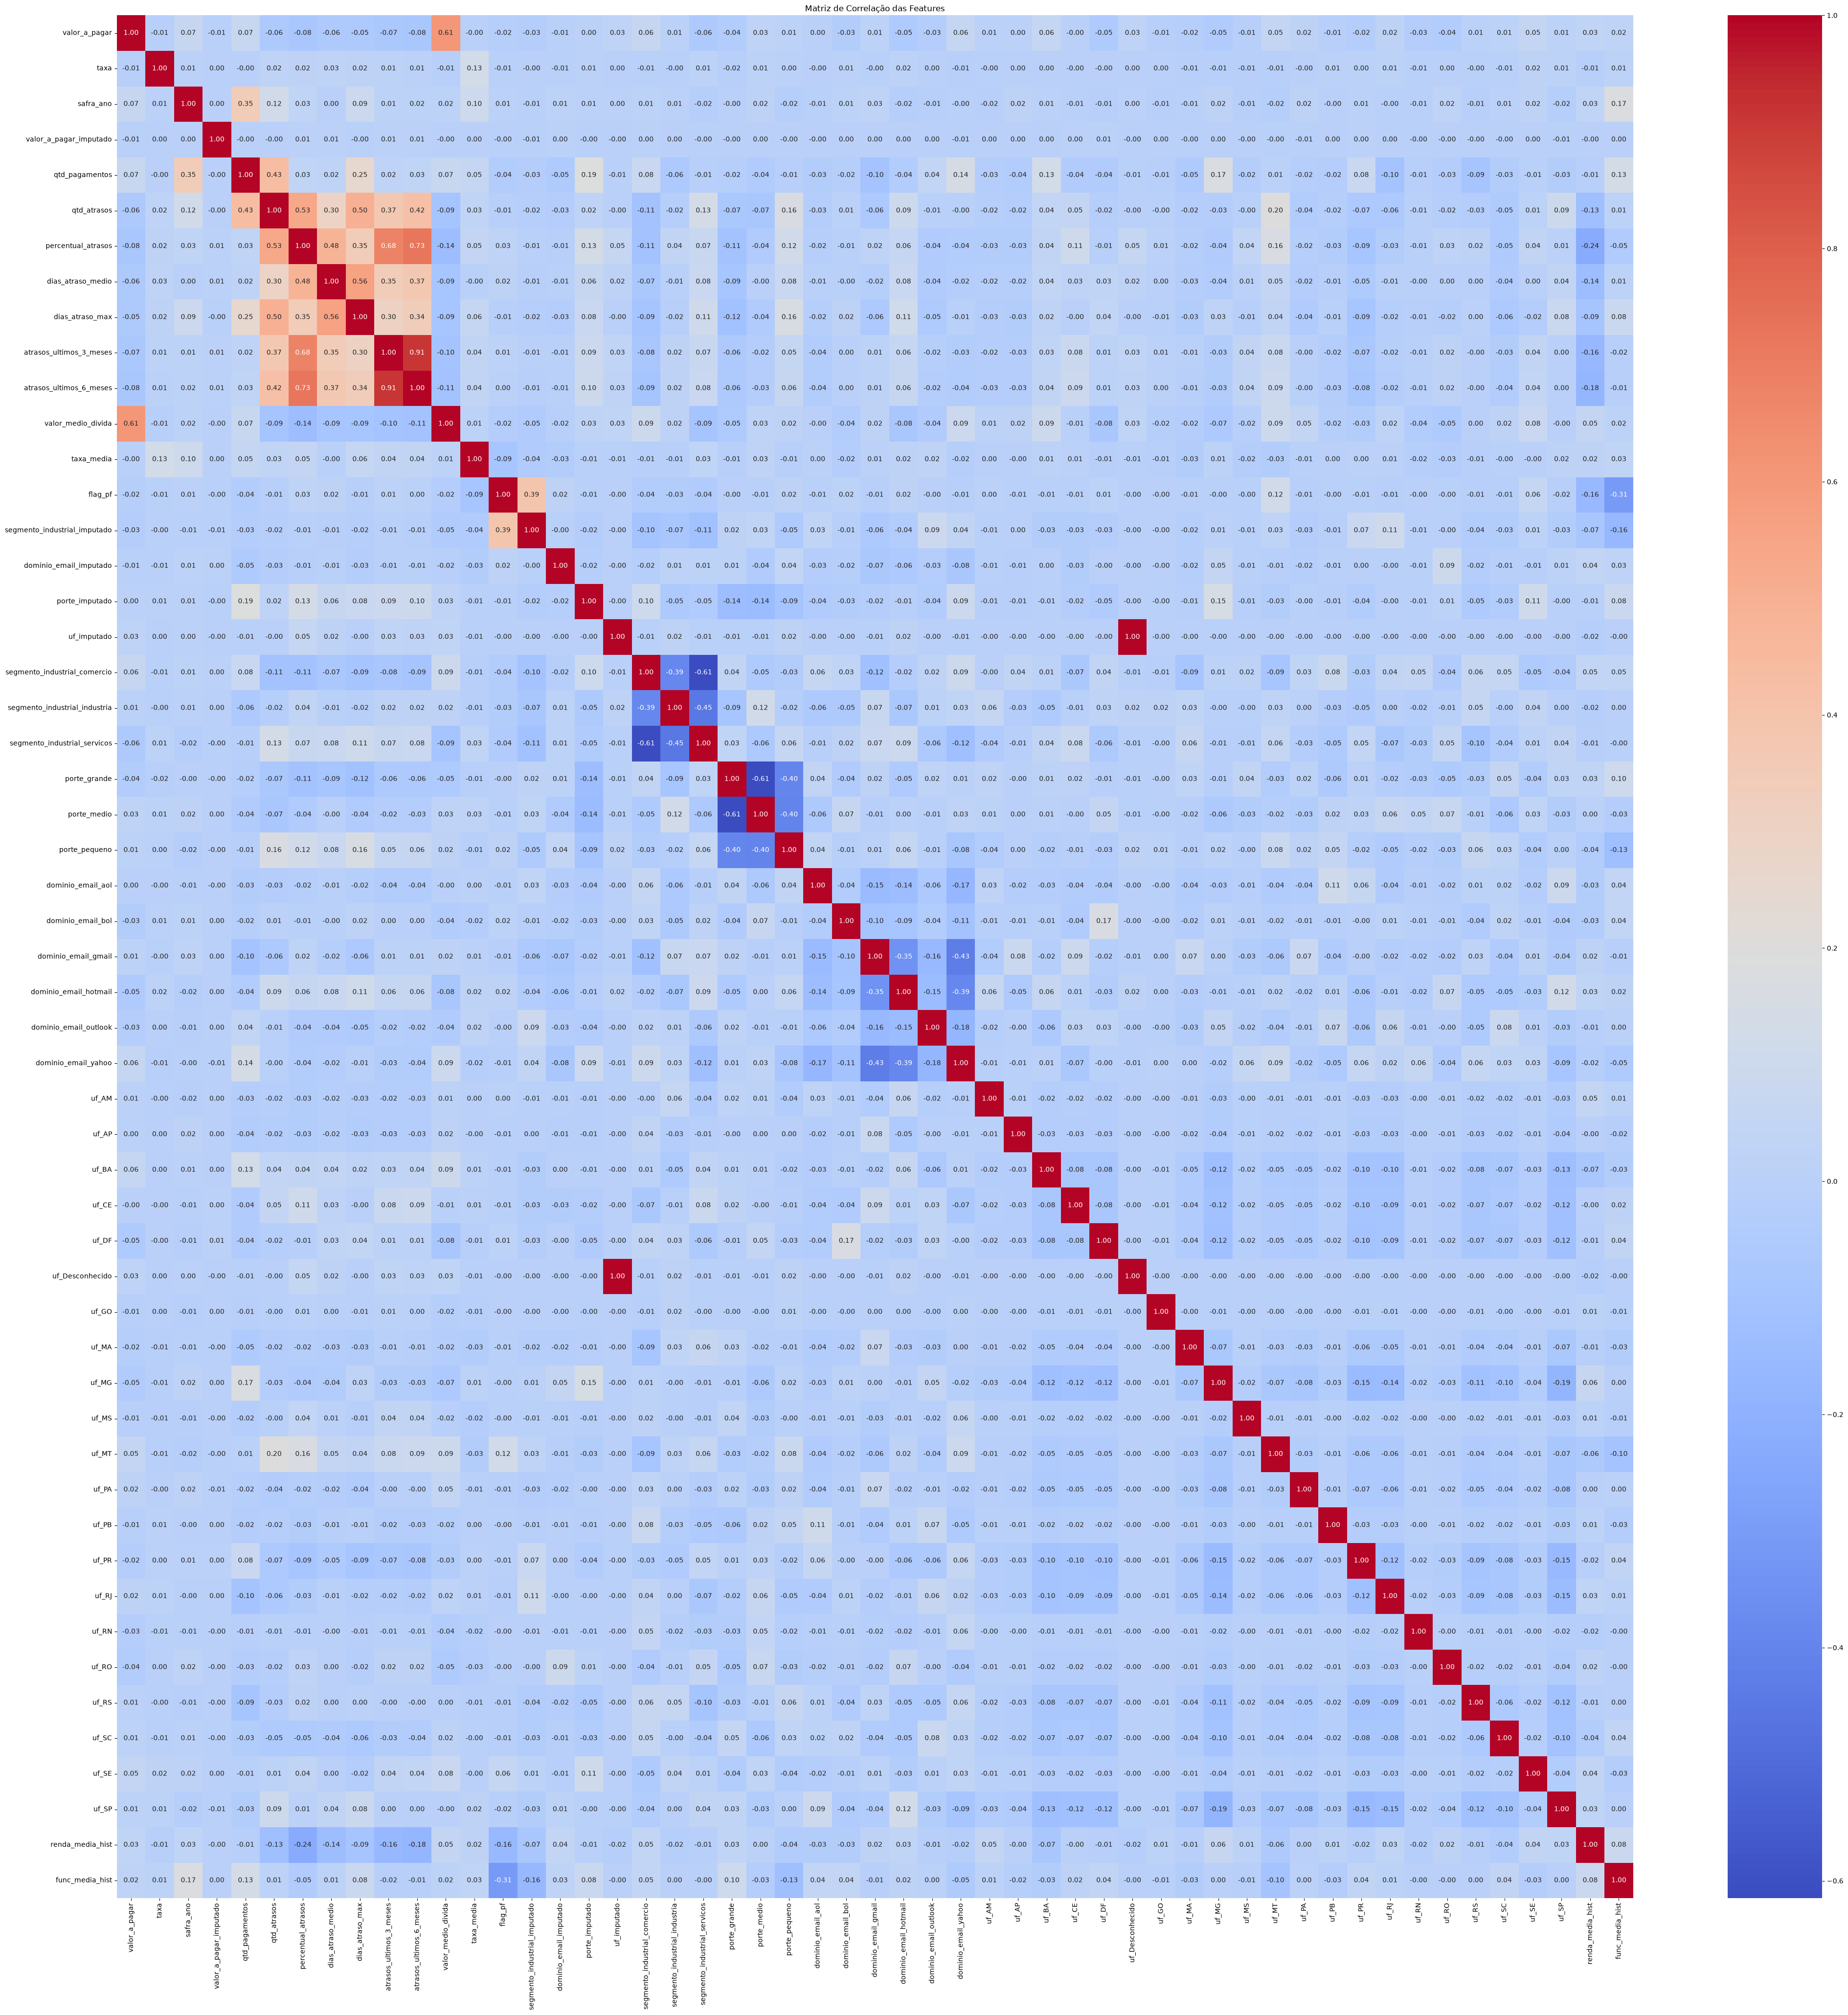

Variáveis para exclusão por correlação >= 0.75:
['atrasos_ultimos_6_meses', 'uf_Desconhecido']


In [54]:
# Análise da reduância das features que afetam o modelo
X_corr, X_colunas_alta_corr = plot_matriz_corr(X, limite_corr=0.75, figsize=(50, 50))

In [55]:
X_limpo = X.drop(columns=X_colunas_alta_corr)

X_limpo.head()

,valor_a_pagar,taxa,safra_ano,valor_a_pagar_imputado,qtd_pagamentos,qtd_atrasos,percentual_atrasos,dias_atraso_medio,dias_atraso_max,atrasos_ultimos_3_meses,...,uf_PR,uf_RJ,uf_RN,uf_RO,uf_RS,uf_SC,uf_SE,uf_SP,renda_media_hist,func_media_hist
0,65463.60,5.99,2018,0,0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,0,1,NaN,NaN
1,60875.80,5.99,2018,0,1,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,0,1,65973.0,99.0
2,45310.25,6.99,2018,0,2,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,0,1,65973.0,99.0
3,84358.95,6.99,2018,0,3,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,0,1,107175.0,99.0
4,48124.40,6.99,2018,0,4,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,0,1,107175.0,99.0


In [56]:
X_limpo.isna().sum()[X_limpo.isna().sum() > 0]

renda_media_hist    992
func_media_hist     992
dtype: int64

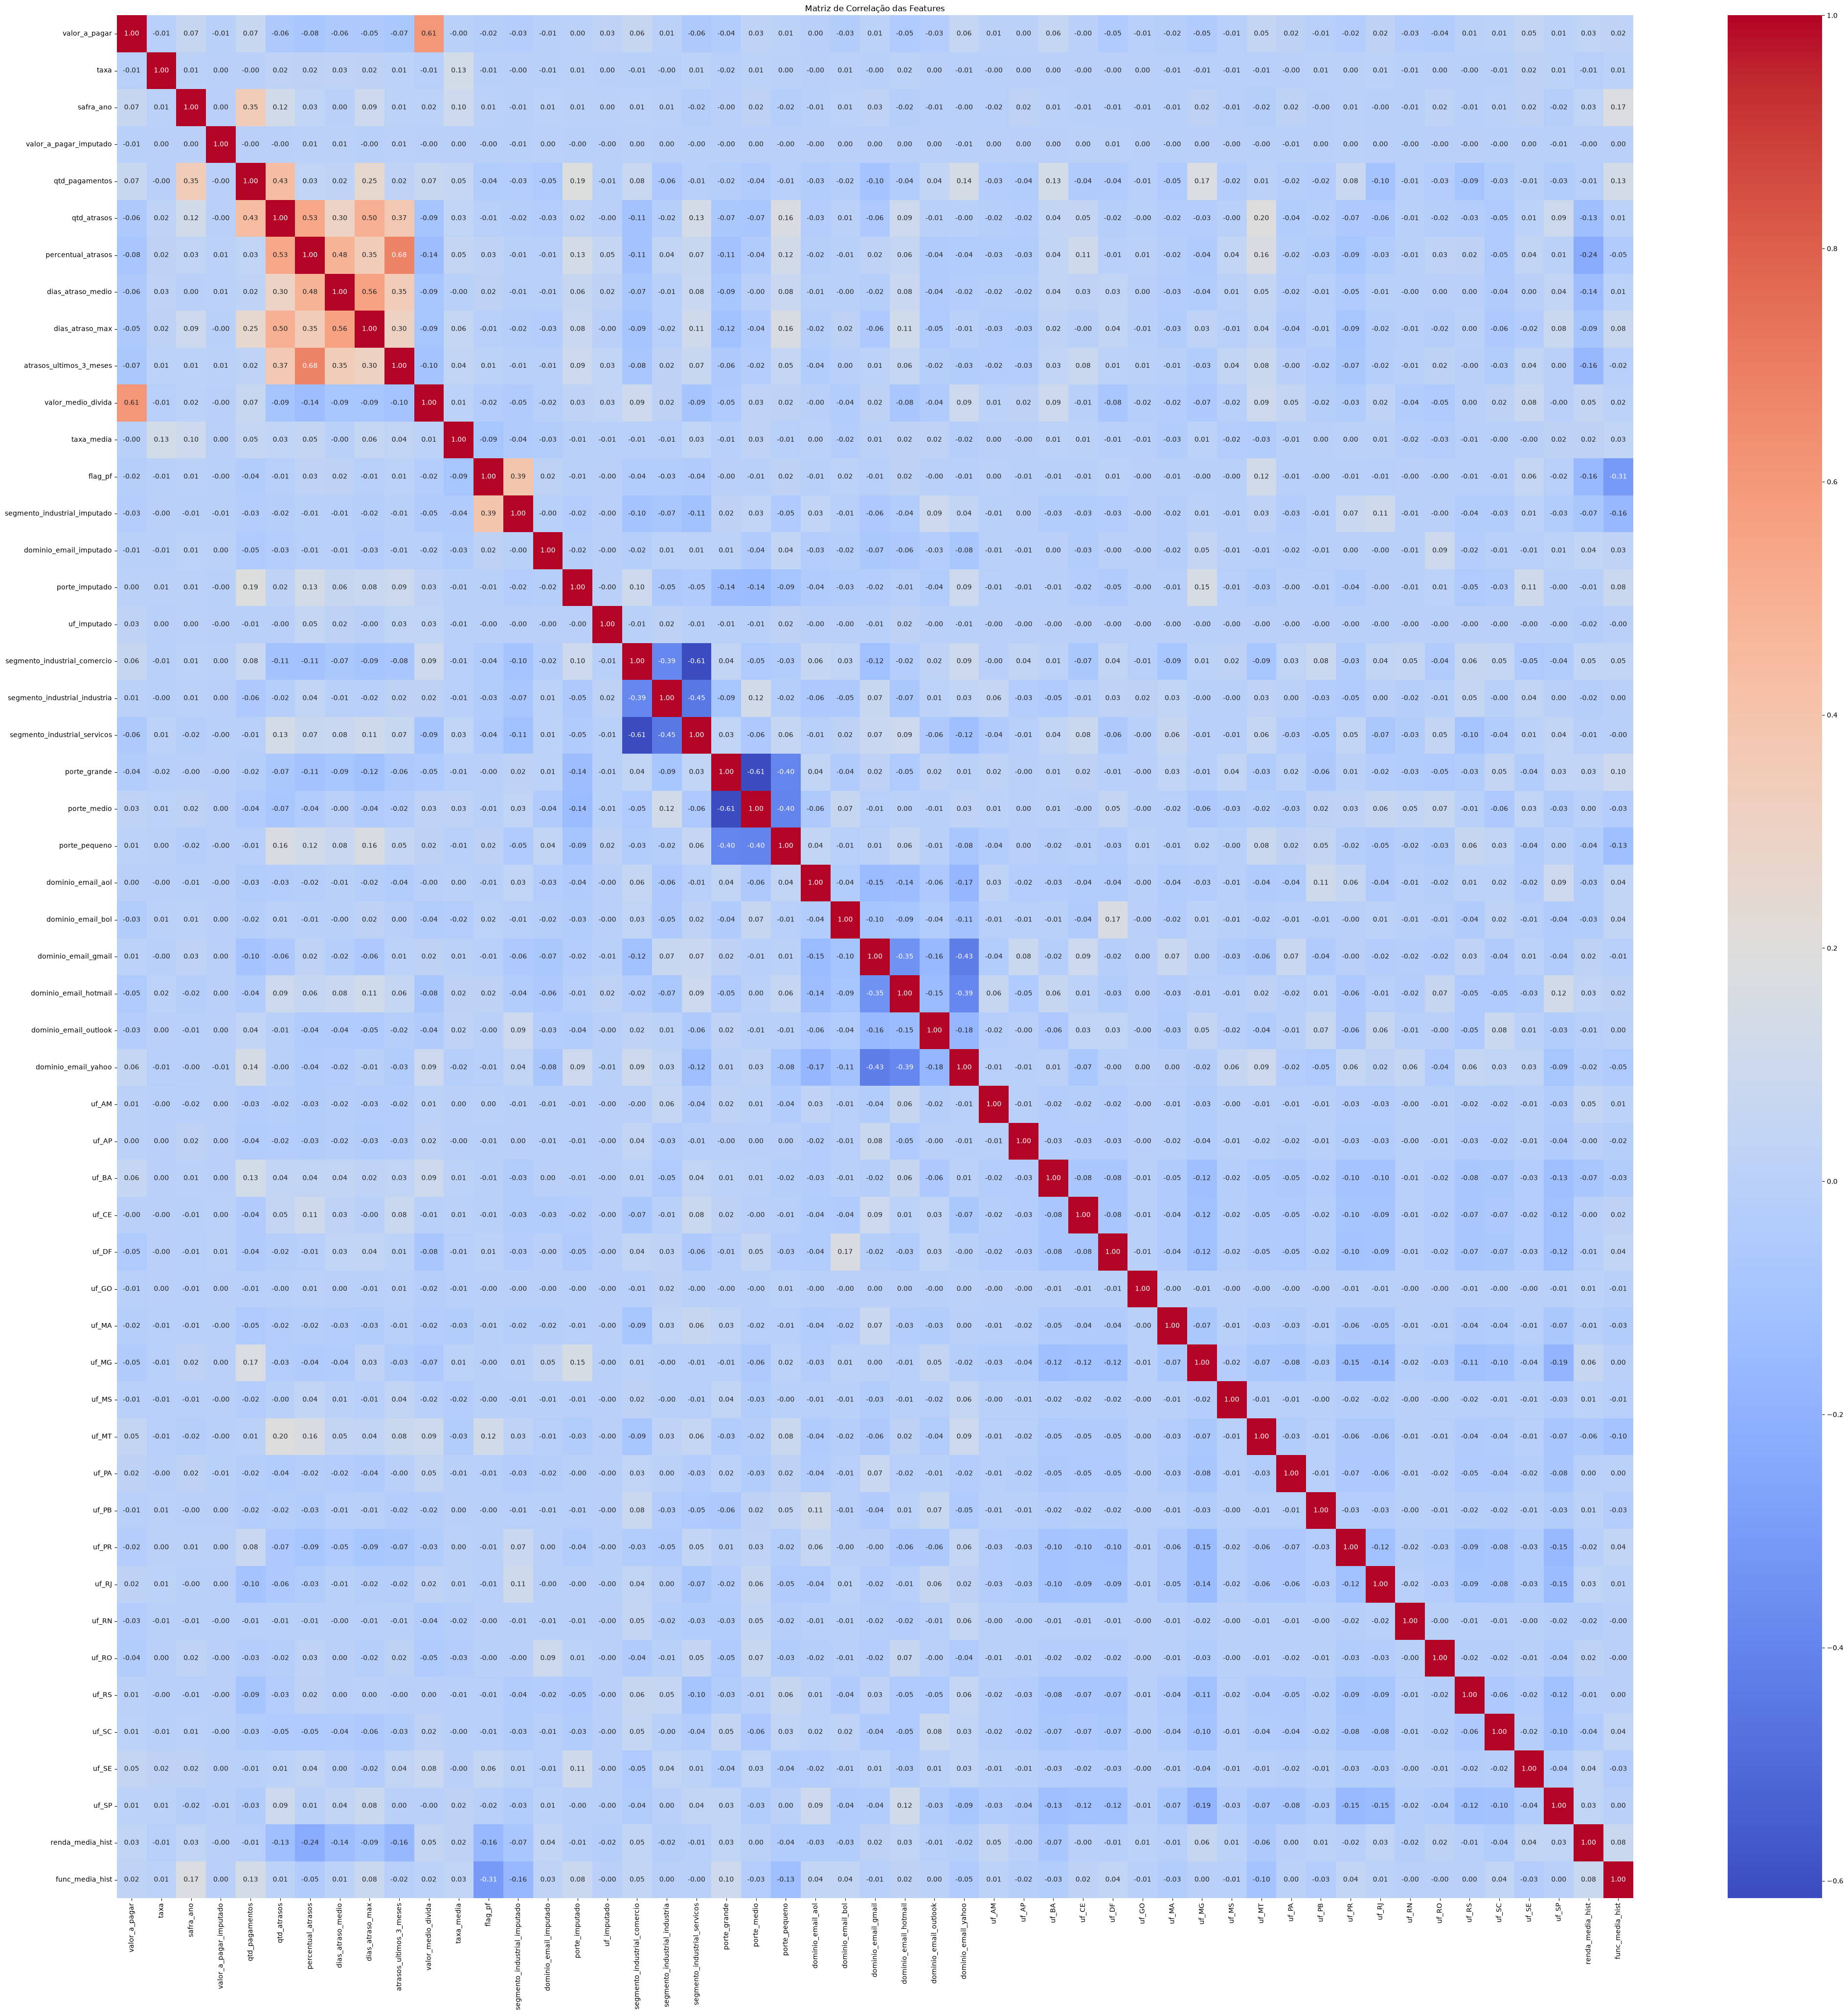

Variáveis para exclusão por correlação >= 0.75:
[]


In [57]:
X_limpo_corr, X_limpo_colunas_alta_corr = plot_matriz_corr(X_limpo, figsize=(50,50))

## Análise de outliers

In [58]:
print(f"{'Métrica / Feature':<40} | {'qt Outliers':<12} | {'Porcentagem':<12}")
print("-" * 62)

colunas_com_outliers_criticos = []

for col in X_limpo.columns:
    # Ignora colunas que são binárias, pois nelas não existem outliers estatísticos
    if X_limpo[col].nunique() <= 2:
        continue

    Q1 = X_limpo[col].quantile(0.25)
    Q3 = X_limpo[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = X_limpo[
        (X_limpo[col] < limite_inferior) | (X_limpo[col] > limite_superior)
        ]
    total_outliers = len(outliers)
    porcentagem = (total_outliers / len(X_limpo)) * 100

    if porcentagem > 5:
        colunas_com_outliers_criticos.append(col)

        print(f"{col:<40} | {total_outliers:<12} | {porcentagem:.2f}%")

Métrica / Feature                        | qt Outliers  | Porcentagem 
--------------------------------------------------------------
valor_a_pagar                            | 4250         | 5.49%
taxa                                     | 13231        | 17.09%
qtd_pagamentos                           | 6825         | 8.82%
qtd_atrasos                              | 12060        | 15.58%
percentual_atrasos                       | 11997        | 15.50%
dias_atraso_medio                        | 12125        | 15.66%
dias_atraso_max                          | 9558         | 12.35%
atrasos_ultimos_3_meses                  | 9120         | 11.78%
taxa_media                               | 4735         | 6.12%
renda_media_hist                         | 4023         | 5.20%


In [59]:
X_limpo[colunas_com_outliers_criticos].describe().round(2)

,valor_a_pagar,taxa,qtd_pagamentos,qtd_atrasos,percentual_atrasos,dias_atraso_medio,dias_atraso_max,atrasos_ultimos_3_meses,taxa_media,renda_media_hist
count,77414.00,77414.00,77414.00,77414.00,77414.00,77414.00,77414.00,77414.00,77414.00,76422.00
mean,46543.88,6.79,102.28,7.25,0.06,1.40,23.89,0.20,6.67,288777.34
std,46229.12,1.80,140.68,25.96,0.15,5.34,63.46,0.62,1.12,79196.06
min,0.10,4.99,0.00,0.00,0.00,0.00,0.00,0.00,0.00,154.00
25%,18838.36,5.99,23.00,0.00,0.00,0.00,0.00,0.00,6.34,246916.67
50%,34764.10,5.99,58.00,0.00,0.00,0.06,3.00,0.00,6.71,285774.26
75%,60817.29,6.99,118.00,3.00,0.05,0.83,20.00,0.00,7.08,325473.38
max,4400000.00,11.99,1150.00,300.00,1.00,458.00,869.00,3.00,11.99,1425097.00


**Conclusão**
- Foram identificadas observações extremas em variáveis como valor_a_pagar, qtd_pagamentos e dias_prazo.
- Entretanto, optou-se por não remover nem truncar os valores, pois:
1. Os modelos utilizados (Random Forest e XGBoost) são robustos à presença de outliers.
2. Em problemas de crédito, valores extremos costumam representar comportamento real dos clientes e podem conter forte sinal preditivo.
3. Testes exploratórios indicaram que as observações extremas não caracterizam erros de coleta de dados.

## Divisão de treino/teste

In [60]:
df_treino_limpo = pd.merge(X_limpo, y, left_index=True, right_index=True)

# Adicionado novamente o safra_ref apenas para
# análise e split treino, val, teste
df_treino_limpo = pd.merge(
    df_treino_limpo,
    df_treino['safra_ref'],
    left_index=True,
    right_index=True
    )

safras_unicas = sorted(df_treino_limpo['safra_ref'].unique())

print(f"Total de safras: {len(safras_unicas)}")
print(f"Primeira safra: {safras_unicas[0]} | Última safra: {safras_unicas[-1]}")

# Definie o corte das safras
# Treino: Primeiras 23 safras (65%)
# Validação: Próximas 6 safras (17%)
# Teste: Últimas 6 safras (18%)

corte_treino_fim = safras_unicas[22]  # Safra índice 22 (23ª safra)
corte_val_fim    = safras_unicas[28]  # Safra índice 28 (29ª safra)

# Separar os datasets por safra
df_treino_set   = df_treino_limpo[df_treino_limpo['safra_ref']  <= corte_treino_fim]
df_val_set      = df_treino_limpo[(df_treino_limpo['safra_ref'] >  corte_treino_fim) & (df_treino_limpo['safra_ref'] <= corte_val_fim)]
df_teste_set    = df_treino_limpo[df_treino_limpo['safra_ref']  >  corte_val_fim]


colunas_drop_X = [
    'id_cliente',
    'data_cadastro',
    'ddd', 
    'safra_ref',
    'data_emissao_documento',
    'data_vencimento',
    'inadimplente',
    'cep_2_dig',
    'safra_ref'
    ]

X_treino = df_treino_set.drop(columns=colunas_drop_X, errors='ignore')
y_treino = df_treino_set['inadimplente']

X_val = df_val_set.drop(columns=colunas_drop_X, errors='ignore')
y_val = df_val_set['inadimplente']

X_teste = df_teste_set.drop(columns=colunas_drop_X, errors='ignore')
y_teste = df_teste_set['inadimplente']

print(f"Tamanho Treino:       {len(X_treino)} (Safras até {corte_treino_fim})")
print(f"Tamanho Validação:    {len(X_val)} (Safras até {corte_val_fim})")
print(f"Tamanho Teste:        {len(X_teste)} (Safras posteriores a {corte_val_fim})")

Total de safras: 35
Primeira safra: 2018-08 | Última safra: 2021-06
Tamanho Treino:       49024 (Safras até 2020-06)
Tamanho Validação:    14123 (Safras até 2020-12)
Tamanho Teste:        14267 (Safras posteriores a 2020-12)


In [61]:
print("Treino - Contagem de Inadimplentes:")
print(y_treino.value_counts(normalize=True))

print("\Validação - Contagem de Inadimplentes:")
print(y_val.value_counts(normalize=True))

print("\nTeste - Contagem de Inadimplentes:")
print(y_teste.value_counts(normalize=True))

Treino - Contagem de Inadimplentes:
inadimplente
0    0.922834
1    0.077166
Name: proportion, dtype: float64
\Validação - Contagem de Inadimplentes:
inadimplente
0    0.94647
1    0.05353
Name: proportion, dtype: float64

Teste - Contagem de Inadimplentes:
inadimplente
0    0.937128
1    0.062872
Name: proportion, dtype: float64


# Modelos

## Random Forest Classifier

In [62]:
modelo_rf = RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
            )

modelo_rf.fit(X_treino, y_treino)

# Probabilidade
y_probs_rf_baseline = modelo_rf.predict_proba(X_teste)[:, 1]

# Pred binária com cutoff padrão 0.5
y_pred_rf_baseline  = modelo_rf.predict(X_teste)

In [63]:
metricas_rf_baseline = calcula_metricas(
    y_teste,
    y_pred_rf_baseline,
    y_probs_rf_baseline,
    'rf_baseline'
    )

metricas_rf_baseline

{'nome_modelo': 'rf_baseline',
 'recall': 0.3701226309921962,
 'precision': 0.7961630695443646,
 'accuracy': 0.9544403168150277,
 'f1_score': 0.5053272450532724,
 'tn': np.int64(13285),
 'fp': np.int64(85),
 'fn': np.int64(565),
 'tp': np.int64(332),
 'roc_auc': 0.9538603706029156,
 'avg_precision': 0.667338890830738,
 'brier_score': 0.03588392093642672}

Average Precision (PR-AUC): 0.67


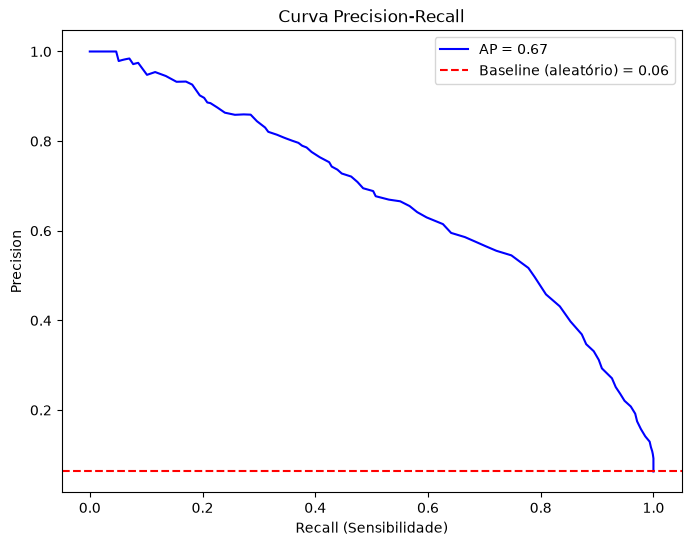

In [64]:
plot_curva_precision_recall(y_teste, y_probs_rf_baseline)

### Tuning

In [65]:
param_grid_rf = {
    'n_estimators':      randint(low=100, high=301),
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(low=2, high=13),
    'min_samples_leaf':  randint(low=1, high=6),
    'bootstrap':         [True, False],
    'max_features':      ["sqrt", "log2", None]
}

In [66]:
modelo_para_tuning_rf = RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
            )

random_search_rf = RandomizedSearchCV(
    estimator=modelo_para_tuning_rf,
    param_distributions=param_grid_rf,
    n_iter=5, # Foi utilizado 5 apenas para propósito de demonstração do tuning
    cv=5,
    scoring='average_precision',
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_treino, y_treino)

modelo_rf_tuning = random_search_rf.best_estimator_
print(f'\n{modelo_rf_tuning}')

y_probs_rf_tuning = modelo_rf_tuning.predict_proba(X_teste)[:, 1]
y_pred_rf_tuning  = modelo_rf_tuning.predict(X_teste)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

RandomForestClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=4, min_samples_split=9,
                       n_estimators=251, n_jobs=-1, random_state=42)


In [67]:
metricas_rf_tuning = calcula_metricas(
    y_teste,
    y_pred_rf_tuning,
    y_probs_rf_tuning,
    'rf_tuning'
    )

metricas_rf_tuning

{'nome_modelo': 'rf_tuning',
 'recall': 0.798216276477146,
 'precision': 0.5864045864045864,
 'accuracy': 0.9519170112847831,
 'f1_score': 0.676109537299339,
 'tn': np.int64(12865),
 'fp': np.int64(505),
 'fn': np.int64(181),
 'tp': np.int64(716),
 'roc_auc': 0.9662169418713922,
 'avg_precision': 0.7108486359467381,
 'brier_score': 0.04485334107880815}

Average Precision (PR-AUC): 0.71


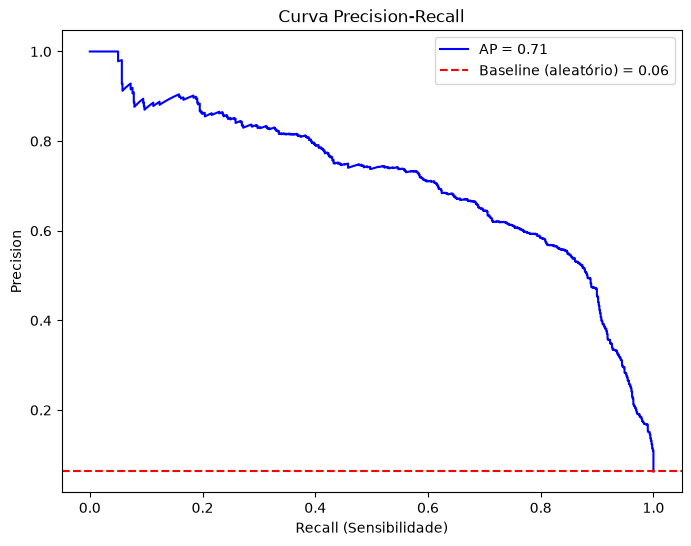

In [68]:
plot_curva_precision_recall(y_teste, y_probs_rf_tuning)

### Calibração do modelo

In [69]:
# Para ajustar a escala numérica das probabilidades, garantindo que
# o risco previsto corresponda ao risco real observado

modelo_calibrado_rf = CalibratedClassifierCV(
    estimator=FrozenEstimator(modelo_rf_tuning),
    method='isotonic'
)

modelo_calibrado_rf.fit(X_val, y_val)

y_probs_rf_calibrado = modelo_calibrado_rf.predict_proba(X_teste)[:, 1]
y_pred_rf_calibrado  = modelo_calibrado_rf.predict(X_teste)

In [70]:
metricas_rf_calibrado = calcula_metricas(
    y_teste,
    y_pred_rf_calibrado,
    y_probs_rf_calibrado,
    'rf_calibrado'
    )

metricas_rf_calibrado

{'nome_modelo': 'rf_calibrado',
 'recall': 0.41025641025641024,
 'precision': 0.7829787234042553,
 'accuracy': 0.9557720614004346,
 'f1_score': 0.5384052670080468,
 'tn': np.int64(13268),
 'fp': np.int64(102),
 'fn': np.int64(529),
 'tp': np.int64(368),
 'roc_auc': 0.9655152344430742,
 'avg_precision': 0.6900300119034861,
 'brier_score': 0.029978879564308808}

Average Precision (PR-AUC): 0.69


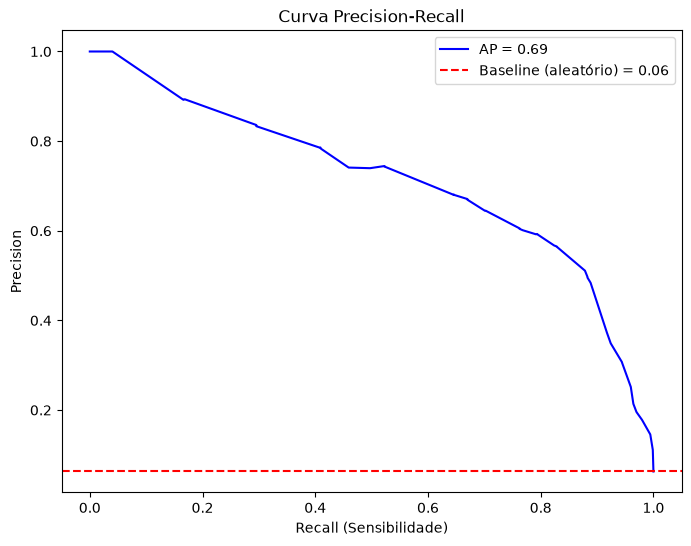

In [71]:
plot_curva_precision_recall(y_teste, y_probs_rf_calibrado)

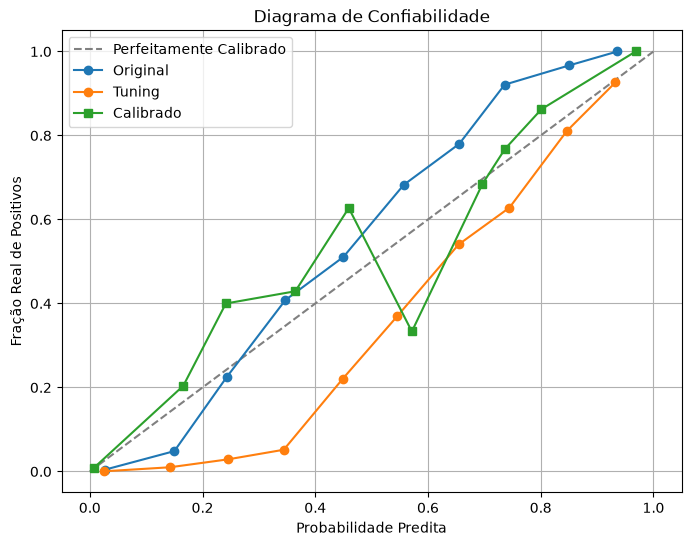

In [72]:
# Compara a curva para o modelo não calibrado e calibrado
prob_true_rf,  prob_pred_rf = calibration_curve(y_teste, y_probs_rf_baseline, n_bins=10, strategy='uniform')
prob_true_tuning_rf,  prob_pred_tunig_rf = calibration_curve(y_teste, y_probs_rf_tuning, n_bins=10, strategy='uniform')
prob_true_cal_rf, prob_pred_calib_rf = calibration_curve(y_teste, y_probs_rf_calibrado, n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfeitamente Calibrado')
plt.plot(prob_pred_rf, prob_true_rf, marker='o', label='Original')
plt.plot(prob_pred_tunig_rf, prob_true_tuning_rf, marker='o', label='Tuning')
plt.plot(prob_pred_calib_rf, prob_true_cal_rf, marker='s', label='Calibrado')

plt.xlabel('Probabilidade Predita')
plt.ylabel('Fração Real de Positivos')
plt.title('Diagrama de Confiabilidade')
plt.legend()
plt.grid(True)
plt.show()

**Conclusão**
- As curvas do modelo Original com Tuning estão praticamente sobrepostas na parte inferior. Isso mostra que, embora o tuning de hiperparâmetros melhore a discriminação (o ranking dos clientes), ele não resolve o problema de calibração por si só e as árvores continuam gerando probabilidades distorcidas.
- Enquanto os modelos não calibrados subestimam o risco nas faixas centrais, o modelo calibrado força as probabilidades a refletirem a realidade estatística

### Análise de overfitting

In [73]:
analise_overfitting(modelo_calibrado_rf, X_treino, y_probs_rf_calibrado)

--- ANÁLISE DE OVERFITTING ---
Brier Score     | Treino: 0.0133 | Teste: 0.0300
ROC-AUC         | Treino: 0.9962 | Teste: 0.9655
Log Loss        | Treino: 0.0447 | Teste: 0.1037
Avg Precision   | Treino: 0.9396 | Teste: 0.6900


**Conclusão**
- Brier Score mostra que erro quadrático das probabilidades estabiliza em 0,0293 e confirma que a calibração isotônica funcionou muito bem e manteve as previsões de risco calibradas na prática.
- ROC-AUC para o teste indica boa capacidade de discrimação pelo modelo.
- Log Loss de 0,1025 no teste demonstra que o modelo não está cometendo erros absurdos de confiança nas previsões para a frente.

## XGBoost

In [74]:
df_y_treino = pd.DataFrame(y_treino)

tamanho_adimp_treino   = df_y_treino[df_y_treino['inadimplente'] == 0].shape[0]
tamanho_inadimp_treino = df_y_treino[df_y_treino['inadimplente'] == 1].shape[0]

scale_pos_weight = (
    tamanho_adimp_treino / tamanho_inadimp_treino    
)

scale_pos_weight

11.959027227068464

In [75]:
modelo_xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

modelo_xgb.fit(X_treino, y_treino)

y_probs_xgb_baseline = modelo_xgb.predict_proba(X_teste)[:, 1]
y_pred_xgb_baseline  = modelo_xgb.predict(X_teste)

In [76]:
metricas_xgb_baseline = calcula_metricas(
    y_teste,
    y_pred_xgb_baseline,
    y_probs_xgb_baseline,
    'xgb_baseline'
    )

metricas_xgb_baseline

{'nome_modelo': 'xgb_baseline',
 'recall': 0.8015607580824972,
 'precision': 0.48450134770889486,
 'accuracy': 0.9339034134716478,
 'f1_score': 0.6039479210415791,
 'tn': np.int64(12605),
 'fp': np.int64(765),
 'fn': np.int64(178),
 'tp': np.int64(719),
 'roc_auc': 0.9559633666280605,
 'avg_precision': 0.6702947789160317,
 'brier_score': 0.050746667268711396}

Average Precision (PR-AUC): 0.67


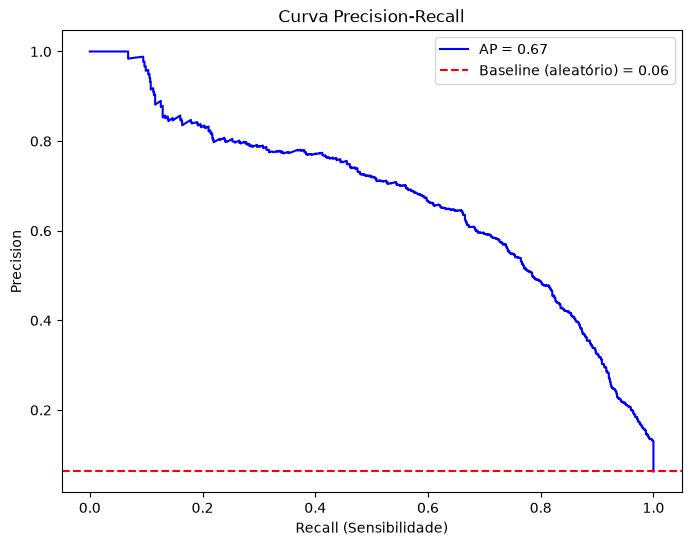

In [77]:
plot_curva_precision_recall(y_teste, y_probs_xgb_baseline)

### Tuning

In [78]:
param_dist_xgb = {
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'n_estimators':     randint(100, 500),
    'max_depth':        randint(3, 10),
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma':            [0, 0.1, 0.2, 0.5]
}

In [79]:
modelo_para_tuning_xgb = XGBClassifier( random_state=42, eval_metric='logloss')

random_search_xgb = RandomizedSearchCV(
    estimator=modelo_para_tuning_xgb,
    param_distributions=param_dist_xgb,
    n_iter=5,
    cv=5,
    scoring='average_precision',
    random_state=42,
    verbose=3
)

random_search_xgb.fit(X_treino, y_treino)

modelo_xgb_tuning = random_search_xgb.best_estimator_
print(f'\n{modelo_xgb_tuning}')

y_probs_xgb_tuning = modelo_xgb_tuning.predict_proba(X_teste)[:, 1]
y_pred_xgb_tuning  = modelo_xgb_tuning.predict(X_teste)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=171, subsample=1.0;, score=0.779 total time=   2.2s
[CV 2/5] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=171, subsample=1.0;, score=0.599 total time=   3.1s
[CV 3/5] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=171, subsample=1.0;, score=0.691 total time=   3.4s
[CV 4/5] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=171, subsample=1.0;, score=0.577 total time=   2.7s
[CV 5/5] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=171, subsample=1.0;, score=0.791 total time=   2.3s
[CV 1/5] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=5, n_estimators=314, subsample=0.8;, score=0.770 total time=   5.1s
[CV 2/5] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.05, max_depth=5, n_estimators

In [80]:
metricas_xgb_tuning = calcula_metricas(
    y_teste,
    y_pred_xgb_tuning,
    y_probs_xgb_tuning,
    'xgb_tuning'
    )

metricas_xgb_tuning

{'nome_modelo': 'xgb_tuning',
 'recall': 0.6711259754738016,
 'precision': 0.7209580838323353,
 'accuracy': 0.9629915188897455,
 'f1_score': 0.6951501154734411,
 'tn': np.int64(13137),
 'fp': np.int64(233),
 'fn': np.int64(295),
 'tp': np.int64(602),
 'roc_auc': 0.9722364667732298,
 'avg_precision': 0.7562922103256186,
 'brier_score': 0.027174318055002755}

Average Precision (PR-AUC): 0.76


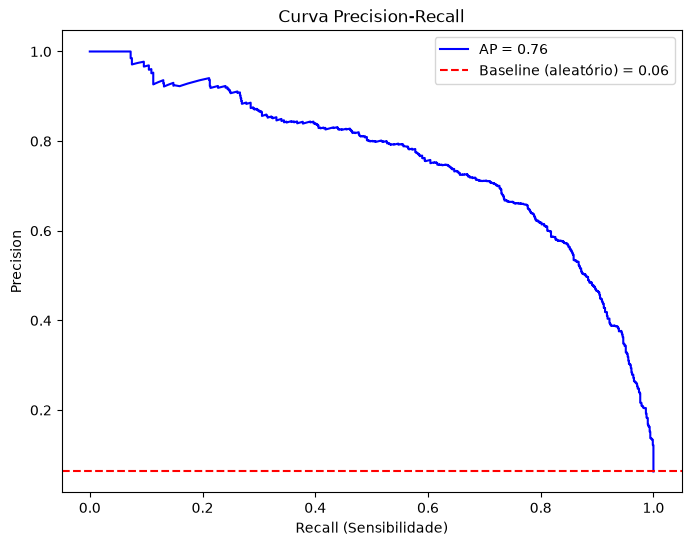

In [81]:
plot_curva_precision_recall(y_teste, y_probs_xgb_tuning)

### Calibração do modelo

In [82]:
modelo_calibrado_xgb = CalibratedClassifierCV(
    estimator=FrozenEstimator(modelo_xgb_tuning),
    method='isotonic'
)

# Ajustar usando dados de validação
modelo_calibrado_xgb.fit(X_val, y_val)

# Obter as probabilidades calibradas no conjunto de teste
y_probs_xgb_calibrado = modelo_calibrado_xgb.predict_proba(X_teste)[:, 1]
y_pred_xgb_calibrado  = modelo_calibrado_xgb.predict(X_teste)

In [83]:
metricas_xgb_calibrado = calcula_metricas(
    y_teste,
    y_pred_xgb_calibrado,
    y_probs_xgb_calibrado,
    'xgb_calibrado'
    )

metricas_xgb_calibrado

{'nome_modelo': 'xgb_calibrado',
 'recall': 0.6410256410256411,
 'precision': 0.740979381443299,
 'accuracy': 0.9633419779911684,
 'f1_score': 0.6873879258816498,
 'tn': np.int64(13169),
 'fp': np.int64(201),
 'fn': np.int64(322),
 'tp': np.int64(575),
 'roc_auc': 0.9718167180721244,
 'avg_precision': 0.7401781781602416,
 'brier_score': 0.02700169128249276}

Average Precision (PR-AUC): 0.74


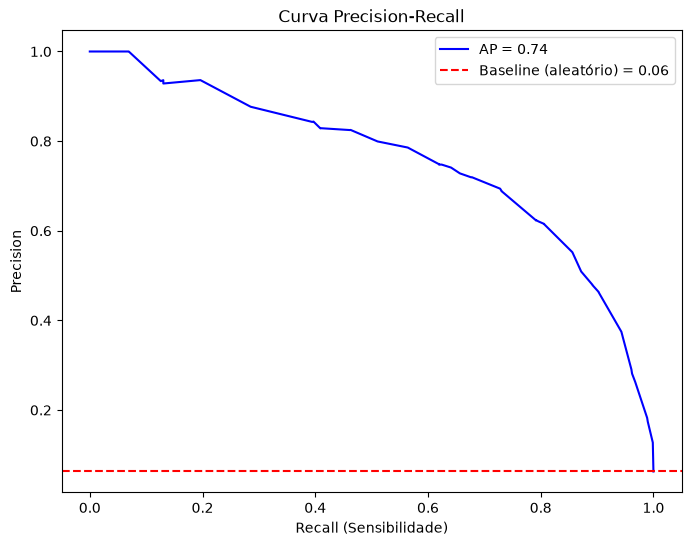

In [84]:
plot_curva_precision_recall(y_teste, y_probs_xgb_calibrado)

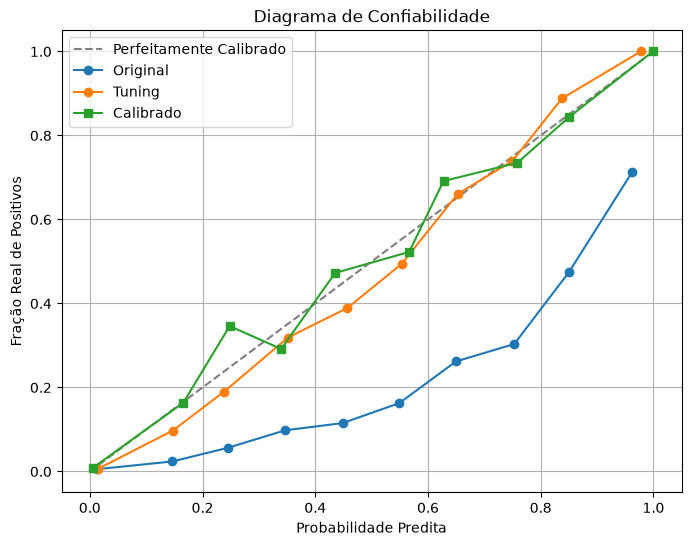

In [85]:
prob_true_xgb,  prob_pred_xgb = calibration_curve(y_teste, y_probs_xgb_baseline, n_bins=10, strategy='uniform')
prob_true_tuning_xgb,  prob_pred_tunig_xgb = calibration_curve(y_teste, y_probs_xgb_tuning, n_bins=10, strategy='uniform')
prob_true_cal_xgb, prob_pred_calib_xgb = calibration_curve(y_teste, y_probs_xgb_calibrado, n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfeitamente Calibrado')
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label='Original')
plt.plot(prob_pred_tunig_xgb, prob_true_tuning_xgb, marker='o', label='Tuning')
plt.plot(prob_pred_calib_xgb, prob_true_cal_xgb, marker='s', label='Calibrado')

plt.xlabel('Probabilidade Predita')
plt.ylabel('Fração Real de Positivos')
plt.title('Diagrama de Confiabilidade')
plt.legend()
plt.grid(True)
plt.show()

### Análise de overfitting

In [86]:
analise_overfitting(modelo_calibrado_xgb, X_treino, y_probs_xgb_calibrado)

--- ANÁLISE DE OVERFITTING ---
Brier Score     | Treino: 0.0252 | Teste: 0.0270
ROC-AUC         | Treino: 0.9833 | Teste: 0.9718
Log Loss        | Treino: 0.0857 | Teste: 0.0947
Avg Precision   | Treino: 0.8484 | Teste: 0.7402


**Conclusão**
- Não há indícios relevantes de overfitting, pois as métricas de desempenho no conjunto de teste permaneceram próximas às observadas no conjunto de treino.
- ROC-AUC apresentou redução pequena
- Brier Score e o Log Loss tiveram aumentos modestos, indicando que o modelo mantém boa capacidade de discriminação e qualidade das probabilidades em dados não vistos.
- Embora a Average Precision tenha apresentado uma queda mais perceptível, o desempenho em teste continua elevado, sugerindo que o modelo generaliza adequadamente e não está excessivamente ajustado aos dados de treinamento.

### Análise SHAP

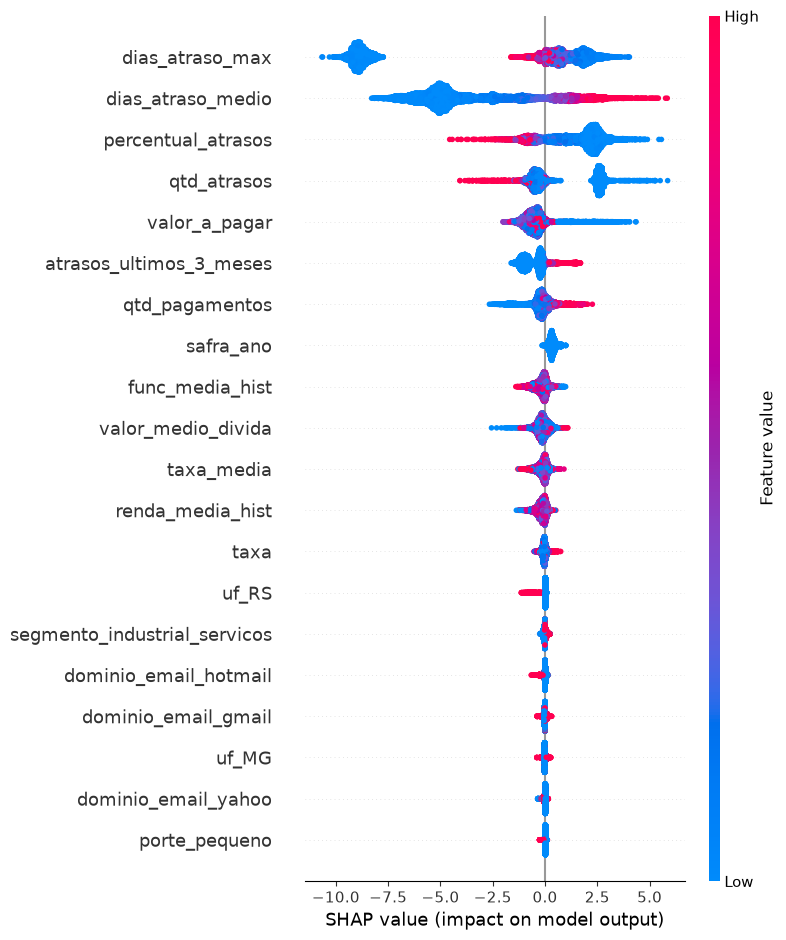

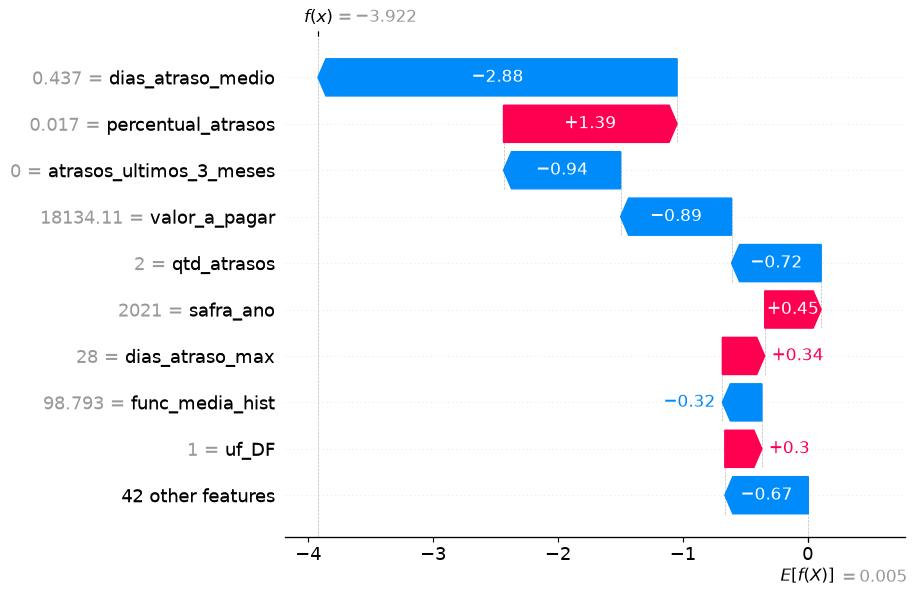

In [87]:
shap.initjs()

explainer = shap.TreeExplainer(modelo_xgb)

X_test_shap = pd.DataFrame(X_teste, columns=X_teste.columns)
shap_values = explainer(X_test_shap)

shap.summary_plot(shap_values, X_test_shap)

# Pega o décimo cliente do set de teste para auditar o porquê do score dele
shap.plots.waterfall(shap_values[10])

**Conclusão**
- As variáveis relacionadas ao histórico de pagamento são os principais direcionadores das previsões do modelo.
- dias_atraso_medio, dias_atraso_max, percentual_atrasos e qtd_atrasos concentram a maior parte da importância preditiva.
- Os resultados indicam que o modelo atribui maior risco a clientes com histórico recorrente de atrasos e reduz o risco para clientes que apresentam comportamento consistente de pagamentos em dia, demonstrando coerência entre os padrões aprendidos e a lógica de negócio esperada para avaliação de inadimplência.

## Métricas

**Nota**
- Embora cada predição binária possa performar melhor com cutoffs diferentes, para as métricas dos modelos optou-se por manter o padrão de 0.5 a fim de todos usarem o mesmo parâmetro.

In [89]:
# Agrupar os dicionários já calculados em uma lista com os nomes dos modelos
tabela_metricas = [
    {"modelo": "Random Forest Baseline", **metricas_rf_baseline},
    {"modelo": "Random Forest Tuning", **metricas_rf_tuning},
    {"modelo": "Random Forest Calibrado", **metricas_rf_calibrado},
    {"modelo": "XGBoost Baseline", **metricas_xgb_baseline},
    {"modelo": "XGBoost Tuning", **metricas_xgb_tuning},
    {"modelo": "XGBoost Calibrado", **metricas_xgb_calibrado}
]

df_metricas = pd.DataFrame(tabela_metricas)

In [97]:
colunas_decimais = [
    'modelo', 'precision', 'recall', 'accuracy', 
    'f1_score', 'roc_auc', 'avg_precision', 'brier_score'
]

df_plot = df_metricas[colunas_decimais].melt(
    id_vars='modelo',
    var_name='metrica',
    value_name='valor'
)

fig = px.bar(
    df_plot,
    x='metrica',
    y='valor',
    color='modelo',
    barmode='group',
    text_auto='.4f',
    title='Comparação de Performance dos Modelos',
    labels={
        'metrica':  'Métrica',
        'valor':    'Score',
        'modelo':   'Modelo'
    },
    color_discrete_sequence=[
        '#1f77b4',
        '#ff7f0e',
        '#2ca02c',
        '#d62728',
        '#9467bd',
        '#17becf'
    ]
)

fig.update_layout(
    title_x=0.5,
    bargap=0.15,
    plot_bgcolor='white',
    legend_title='Modelo',
    xaxis=dict(
        title='Métrica',
        showgrid=True,
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Score',
        showgrid=True,
        showticklabels=False,
        gridcolor='lightgray'
    )
)

fig.show()

In [100]:
# Garante que apenas as colunas numéricas sejam arredondadas para exibição limpa
df_heatmap = df_metricas[colunas_decimais].set_index('modelo')
df_heatmap_num = df_heatmap.select_dtypes(include='number').round(4)

fig = px.imshow(
    df_heatmap_num,
    text_auto=True,
    aspect='auto',
    color_continuous_scale='Viridis',
    title='Comparação de Métricas por Modelo'
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    xaxis_title='Métricas',
    yaxis_title='Modelos'
)

fig.show()

**Conclusão**
- Uma redução no Brier Score indica que as probabilidades numéricas emitidas pelo modelo XGBoost Calibrado refletem de forma mais realista o risco percentual de inadimplência do cliente.

In [110]:
melhor_modelo = modelo_calibrado_xgb

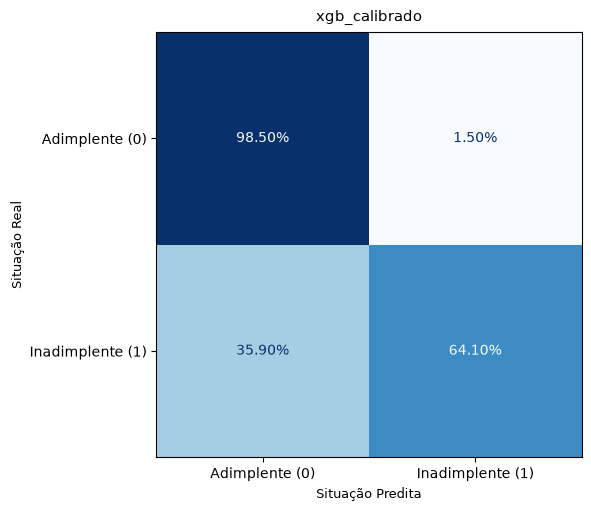

In [101]:
plot_matriz_confusao(y_teste, y_pred_xgb_calibrado, normalize='true', nome_modelo='xgb_calibrado')

**Conclusão**
- O modelo calibrado apresenta excelente especificidade (98,50%), minimizando ações de 
  cobrança desnecessárias sobre bons pagadores.
- Em contrapartida, a sensibilidade de 64,10% no cutoff padrão de 0,5 indica que ~36% dos clientes que efetivamente atrasarão não são capturados nesse ponto de corte.
- Dado que o custo de negócio de um Falso Negativo tende a ser maior que o de um Falso Positivo neste contexto, uma possibilidade seria avaliar o cutoff através da análise de custo.

# ML Flow

In [102]:
import mlflow 
import mlflow.sklearn


mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("previsao_inadimplencia_2")

# Estrutura unificada com os dicionários individuais
dados_tabela = [
    {"modelo": "Random Forest Baseline", "run_name": "rf_baseline", "modelo_obj": modelo_rf, **metricas_rf_baseline},
    {"modelo": "Random Forest Tuning", "run_name": "rf_tuning", "modelo_obj": modelo_rf_tuning, **metricas_rf_tuning},
    {"modelo": "Random Forest Calibrado", "run_name": "rf_calibrado", "modelo_obj": modelo_calibrado_rf, **metricas_rf_calibrado},
    {"modelo": "XGBoost Baseline", "run_name": "xgb_baseline", "modelo_obj": modelo_xgb, **metricas_xgb_baseline},
    {"modelo": "XGBoost Tuning", "run_name": "xgb_tuning", "modelo_obj": modelo_xgb_tuning, **metricas_xgb_tuning},
    {"modelo": "XGBoost Calibrado", "run_name": "xgb_calibrado", "modelo_obj": modelo_calibrado_xgb, **metricas_xgb_calibrado}
]


features_dict = {
    "n_features": X_treino.shape[1],
    "features": list(X_treino.columns)
}

tipos_confiaveis = [
    "sklearn.calibration._CalibratedClassifier",
    "xgboost.core.Booster",
    "xgboost.sklearn.XGBClassifier"
]

# Salva os dados no MLFlow
for cfg in dados_tabela:
    with mlflow.start_run(run_name=cfg["run_name"]):
        modelo = cfg["modelo_obj"]

        mlflow.log_param("modelo", type(modelo).__name__)
        mlflow.log_param("n_features", X_treino.shape[1])
        mlflow.log_param("target", "inadimplente")

        if hasattr(modelo, "get_params"):
            mlflow.log_params(modelo.get_params())

        chaves_excluidas = {"modelo", "run_name", "modelo_obj", "nome_modelo"}
        for metric_name, valor in cfg.items():
            if metric_name not in chaves_excluidas and valor is not None:
                mlflow.log_metric(metric_name, float(valor))

        mlflow.log_dict(
            features_dict,
            "features.json"
        )

        mlflow.sklearn.log_model(
            sk_model=modelo,
            name="model",
            skops_trusted_types=tipos_confiaveis
        )

print("Experimentos e DataFrame registrados com sucesso!")

🏃 View run rf_baseline at: http://localhost:5000/#/experiments/2/runs/c7bd59dd8b104097ac89d0c8f3716298
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run rf_tuning at: http://localhost:5000/#/experiments/2/runs/7ab297c83526450db2d3c0170e078e01
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run rf_calibrado at: http://localhost:5000/#/experiments/2/runs/4e064325767d432a894f7b1d7727abb3
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run xgb_baseline at: http://localhost:5000/#/experiments/2/runs/082793e210f2411a94a55d55683baf3c
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run xgb_tuning at: http://localhost:5000/#/experiments/2/runs/fef4bfc46b18400ea01d8023f691feaf
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run xgb_calibrado at: http://localhost:5000/#/experiments/2/runs/d9e7741ddb9c44f3a821382712a6c796
🧪 View experiment at: http://localhost:5000/#/experiments/2
Experimentos e DataFr

# Dataset de produção

In [111]:
cols_historico = [
    'qtd_pagamentos', 'qtd_atrasos', 'percentual_atrasos',
    'dias_atraso_medio', 'dias_atraso_max',
    'atrasos_ultimos_3_meses', 'atrasos_ultimos_6_meses',
    'valor_medio_divida', 'taxa_media'
]

# Para ser mais fiel ao que o modelo aprendeu, uma alternativa foi
# pegar o último valor conhecido de cada cliente
historico_ultimo_estado = (
    historico_pagamentos
    .sort_values(['id_cliente', 'safra_ref'])
    .groupby('id_cliente')[cols_historico]
    .last()
    .reset_index()
)

In [112]:
df_prod = pd.read_csv(DATA_DIR / 'base_pagamentos_teste.csv',
                      sep=';',
                      encoding='utf-8'
                      )

df_prod.columns = df_prod.columns.str.lower()
df_prod['id_cliente'] = df_prod['id_cliente'].astype(str)
df_prod['data_emissao_documento'] = pd.to_datetime(df_prod['data_emissao_documento'])
df_prod['data_vencimento'] = pd.to_datetime(df_prod['data_vencimento'])

# Cria a flag de imputação baseada na presença ou ausência de um valor para o modelo
df_prod['valor_a_pagar_imputado'] = df_prod['valor_a_pagar'].isnull().astype(int)

# Preenche valor_a_pagar com a mediana da MESMA safra (mapeamento por valor, não por índice)
df_prod['valor_a_pagar'] = df_prod['valor_a_pagar'].fillna(
    df_prod['safra_ref'].map(mediana_por_safra)
)
# Fallback: caso a safra de produção não exista no histórico de mediana_por_safra
df_prod['valor_a_pagar'] = df_prod['valor_a_pagar'].fillna(mediana_por_safra.median())

df_prod['safra_ano'] = df_prod['safra_ref'].str[:4].astype(int)

df_prod['valor_a_pagar_log'] = np.log1p(df_prod['valor_a_pagar'])

df_prod = cria_features_temporais(df_prod)

df_prod = df_prod.merge(df_base_cadast_encoded, on='id_cliente', how='left')

df_prod = df_prod.merge(historico_ultimo_estado, on='id_cliente', how='left')

# Último estado conhecido de renda/funcionários (já criado antes, uma única vez)
df_prod = df_prod.merge(info_ultimo_estado, on='id_cliente', how='left')

# Flag para clientes 100% novos, sem nenhum histórico de pagamento nem de base_info
df_prod['cliente_novo_sem_historico'] = (
    df_prod['qtd_pagamentos'].isna() & df_prod['renda_media_hist'].isna()
).astype(int)

df_prod = df_prod.sort_values(['id_cliente', 'data_emissao_documento']).reset_index(drop=True)

df_prod

,id_cliente,safra_ref,data_emissao_documento,data_vencimento,valor_a_pagar,taxa,valor_a_pagar_imputado,safra_ano,valor_a_pagar_log,dias_prazo,...,percentual_atrasos,dias_atraso_medio,dias_atraso_max,atrasos_ultimos_3_meses,atrasos_ultimos_6_meses,valor_medio_divida,taxa_media,renda_media_hist,func_media_hist,cliente_novo_sem_historico
0,1000372849175668062,2021-08,2021-08-03,2021-08-23,67156.80,4.99,0,2021,11.114800,20,...,0.0,0.0,0.0,0.0,0.0,48994.393611,7.017778,246446.241379,103.538462,0
1,1000372849175668062,2021-08,2021-08-11,2021-08-30,68730.80,4.99,0,2021,11.137967,19,...,0.0,0.0,0.0,0.0,0.0,48994.393611,7.017778,246446.241379,103.538462,0
2,1000372849175668062,2021-08,2021-08-26,2021-09-20,300.00,6.99,0,2021,5.707110,25,...,0.0,0.0,0.0,0.0,0.0,48994.393611,7.017778,246446.241379,103.538462,0
3,1000372849175668062,2021-08,2021-08-30,2021-09-20,69700.50,6.99,0,2021,11.151977,21,...,0.0,0.0,0.0,0.0,0.0,48994.393611,7.017778,246446.241379,103.538462,0
4,1000372849175668062,2021-09,2021-09-16,2021-10-04,71912.15,4.99,0,2021,11.183214,18,...,0.0,0.0,0.0,0.0,0.0,48994.393611,7.017778,246446.241379,103.538462,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12270,988707525807573448,2021-09,2021-09-27,2021-10-25,56007.61,6.99,0,2021,10.933261,28,...,0.0,0.0,0.0,0.0,0.0,70377.453333,6.601111,306951.625000,137.200000,0
12271,988707525807573448,2021-10,2021-10-06,2021-11-03,56511.90,6.99,0,2021,10.942224,28,...,0.0,0.0,0.0,0.0,0.0,70377.453333,6.601111,306951.625000,137.200000,0
12272,988707525807573448,2021-10,2021-10-11,2021-11-05,56995.31,6.99,0,2021,10.950742,25,...,0.0,0.0,0.0,0.0,0.0,70377.453333,6.601111,306951.625000,137.200000,0
12273,988707525807573448,2021-10,2021-10-12,2021-11-08,58952.69,6.99,0,2021,10.984507,27,...,0.0,0.0,0.0,0.0,0.0,70377.453333,6.601111,306951.625000,137.200000,0


In [119]:
features_treino = X_treino.columns
X_prod = df_prod[features_treino]
X_prod

,valor_a_pagar,taxa,safra_ano,valor_a_pagar_imputado,qtd_pagamentos,qtd_atrasos,percentual_atrasos,dias_atraso_medio,dias_atraso_max,atrasos_ultimos_3_meses,...,uf_PR,uf_RJ,uf_RN,uf_RO,uf_RS,uf_SC,uf_SE,uf_SP,renda_media_hist,func_media_hist
0,67156.80,4.99,2021,0,36.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,246446.241379,103.538462
1,68730.80,4.99,2021,0,36.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,246446.241379,103.538462
2,300.00,6.99,2021,0,36.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,246446.241379,103.538462
3,69700.50,6.99,2021,0,36.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,246446.241379,103.538462
4,71912.15,4.99,2021,0,36.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,246446.241379,103.538462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12270,56007.61,6.99,2021,0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,306951.625000,137.200000
12271,56511.90,6.99,2021,0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,306951.625000,137.200000
12272,56995.31,6.99,2021,0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,306951.625000,137.200000
12273,58952.69,6.99,2021,0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,306951.625000,137.200000


In [120]:
X_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   valor_a_pagar                  12275 non-null  float64
 1   taxa                           12275 non-null  float64
 2   safra_ano                      12275 non-null  int64  
 3   valor_a_pagar_imputado         12275 non-null  int64  
 4   qtd_pagamentos                 12047 non-null  float64
 5   qtd_atrasos                    12047 non-null  float64
 6   percentual_atrasos             12047 non-null  float64
 7   dias_atraso_medio              12047 non-null  float64
 8   dias_atraso_max                12047 non-null  float64
 9   atrasos_ultimos_3_meses        12047 non-null  float64
 10  valor_medio_divida             12047 non-null  float64
 11  taxa_media                     12047 non-null  float64
 12  flag_pf                        12237 non-null 

In [121]:
y_probs_prod = melhor_modelo.predict_proba(X_prod)[:, 1]

y_probs_prod_series = pd.Series(y_probs_prod, name='PROBABILIDADE_INADIMPLENCIA')

df_pred_prod = (
    df_prod[['id_cliente', 'safra_ref']]
    .merge(
        y_probs_prod_series,
        left_index=True,
        right_index=True,
        how='left',
        validate='1:1'
        )
    .sort_values(by='PROBABILIDADE_INADIMPLENCIA', ascending=False)
    .reset_index(drop=True)
    )

df_pred_prod.columns = df_pred_prod.columns.str.upper()
df_pred_prod

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,7815839878620843192,2021-09,1.0
1,7815839878620843192,2021-10,1.0
2,7815839878620843192,2021-09,1.0
3,3421433989501830226,2021-07,1.0
4,3421433989501830226,2021-10,1.0
...,...,...,...
12270,968400235888951633,2021-10,0.0
12271,968400235888951633,2021-10,0.0
12272,968400235888951633,2021-10,0.0
12273,968400235888951633,2021-10,0.0


In [117]:
df_pred_prod.to_csv(DATA_DIR / 'submissao_case.csv', index=False)

In [118]:
fig = px.histogram(
    df_pred_prod,
    x='PROBABILIDADE_INADIMPLENCIA',
    nbins=100,
    title='Distribuição do Valor de Probabilidade Percentual',
    labels={
        'valor_a_pagar': 'Probabilidade (%)',
        'count': 'Qt. Ocorrências'
        },
    color_discrete_sequence=['#1f77b4']
)

fig.update_layout(
    bargap=0.1,
    title_x=0.5,
    plot_bgcolor='white',
    xaxis=dict(
        title='Probabilidade (%)',
        showgrid=True,
        gridcolor='lightgray'
        ),
    yaxis=dict(
        title='Qt. Clientes',
        showticklabels=True,
        showgrid=True,
        gridcolor='lightgray'
        )
)

fig.show()